This notebook was prepared by Mario Paulin to show a complete end-to-end data science project including data exploration, preprocessing, feature engineering, model training, and evaluation. 

The objective of this excercise is to analyze a dataset and identify the main factors associated with heart disease. Then, to apply a predictive model and evaluate what are the main contributing factors and discuss the results. 

# Descriptive and Exploratory Data Analysis 

I begin by loading the data and conducting some descriptive analysis on the variables. 

In [673]:
### This cell will load all the required libraries. Please make sure you have them installed.
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import boxcox
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score
from itertools import product
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import sklearn

In [674]:
# Define the column names based on the .names file
column_names = [
    "age",       # 1. #3
    "sex",       # 2. #4
    "cp",        # 3. #9
    "trestbps",  # 4. #10
    "chol",      # 5. #12
    "fbs",       # 6. #16
    "restecg",   # 7. #19
    "thalach",   # 8. #32
    "exang",     # 9. #38
    "oldpeak",   # 10. #40
    "slope",     # 11. #41
    "ca",        # 12. #44
    "thal",      # 13. #51
    "target"        # 14. #58 (target variable)
]


In [ ]:
# Load the dataset with the specified column names
## Data provenance: https://archive.ics.uci.edu/dataset/45/heart+disease the dataset used is the processed Cleveland dataset 
## place the correct path to the dataset in the data_path variable
data_path = r"C:\Users\mario\OneDrive\Documents\pfizer\data\processed.cleveland.data"
data = pd.read_csv(data_path, names=column_names, header=None)  

# Display the first few rows of the dataset
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [676]:
# Dictionary of relevant variables and their descriptions
relevant_variable_descriptions = {
    "age": "Age in years",
    "sex": "Sex (1 = male; 0 = female)",
    "cp": "Chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic)",
    "trestbps": "Resting blood pressure (in mm Hg on admission to the hospital)",
    "chol": "Serum cholesterol in mg/dl",
    "fbs": "Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)",
    "restecg": "Resting electrocardiographic results (0 = normal; 1 = ST-T wave abnormality; 2 = left ventricular hypertrophy)",
    "thalach": "Maximum heart rate achieved",
    "exang": "Exercise-induced angina (1 = yes; 0 = no)",
    "oldpeak": "ST depression induced by exercise relative to rest",
    "slope": "The slope of the peak exercise ST segment (1 = upsloping; 2 = flat; 3 = downsloping)",
    "ca": "Number of major vessels (0-3) colored by fluoroscopy",
    "thal": "Thalassemia (3 = normal; 6 = fixed defect; 7 = reversible defect)",
    "num": "Diagnosis of heart disease (0 = < 50% diameter narrowing; 1 = > 50% diameter narrowing)"
}

In [677]:
# I need to recode the target variable as it seems it was kept with the 5 original classes 
data['target'] = data['target'].apply(lambda x: 0 if x == 0 else 1)

# Verify the recoding
print("Target variable value counts after recoding:")
print(data['target'].value_counts())

# Verify the changes
print(data['ca'].unique())
print(data['thal'].unique())

## There are some recording errors in the dataset, specifically in the 'ca' and 'thal' columns.
# Replace '?' with appropriate values and convert to integers
data['ca'] = data['ca'].replace('?', 4).astype(float).astype(int)
data['thal'] = data['thal'].replace('?', 0).astype(float).astype(int)

# Verify the changes
print("Unique values in 'ca':", data['ca'].unique())
print("Unique values in 'thal':", data['thal'].unique())


Target variable value counts after recoding:
target
0    164
1    139
Name: count, dtype: int64
['0.0' '3.0' '2.0' '1.0' '?']
['6.0' '3.0' '7.0' '?']
Unique values in 'ca': [0 3 2 1 4]
Unique values in 'thal': [6 3 7 0]


In [678]:
### Now we begin the data exploration. 
## First I will check the data types of the columns and if there are any missing values.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 33.3 KB


Before starting to explore the data, I did some basic research on the subject matter. 

Sex: We should expect males to have higher tendency towards heart disease as per https://www.louisianaheart.org/blog/do-men-have-a-higher-risk-for-heart-disease

CP: Can be a syntom or caused by heart disease. https://www.mayoclinic.org/diseases-conditions/chest-pain/symptoms-causes/syc-20370838

Trestbps: High blood pressure can be associated with heart disease and chest pain. https://utswmed.org/medblog/high-blood-pressure-heart-disease/ 

chol: high colesterol increases risk of heart disease https://www.cdc.gov/cholesterol/about/index.html#:~:text=As%20cholesterol%20(plaque)%20builds%20up,death%20in%20the%20United%20States.

fbs: relationship may not be linear, having elevated or low levels may be associated with heart disease. https://pmc.ncbi.nlm.nih.gov/articles/PMC3687304/

restecg: It seems reasonable that values different than zero could be indicative of underlying conditions. https://ascotcardiologygroup.co.nz/services/diagnostic-resting-ecg/#:~:text=What%20is%20a%20Diagnostic%20Resting,of%20a%20previous%20heart%20attack.


thalach: I did not find anything specific about the association with heart disease, but is may be correlated with other variables such as age, cp, chol, etc... https://austinpublishinggroup.com/austin-cardiology/fulltext/cardiology-v4-id1021.pdf

exang: a common complain of patients with heart disease. https://pubmed.ncbi.nlm.nih.gov/4068968/

oldpeak: some higher values may be associated with heart disease https://pmc.ncbi.nlm.nih.gov/articles/PMC1768611/#:~:text=Exercise%20induced%20ST%20segment%20depression,diagnosis%20of%20obstructive%20coronary%20atherosclerosis.&text=It%20has%20also%20been%20associated,coronary%20artery%20disease%20(CAD).

slope: Some values are predictive of hear disease https://pubmed.ncbi.nlm.nih.gov/3739881/


ca: number of major vessels colored by fluoroscopy. (https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/fluoroscopy-procedure)

thal: seems to be Thalassemia. If severe it can be associated to heart disease through iron overload or other mechanisms. https://www.mayoclinic.org/diseases-conditions/thalassemia/symptoms-causes/syc-20354995


We have 14 variables for the 303 observations. All of the variables are numerical and most of the variables are float. Most of the variables should be categorical. It seems there are no missing values in the dataset. 

In [679]:
## Now I will check the number of unique values in each column.
## This will help us understand the data better and check which variables are categorical.
# Get the number of unique values for each column
unique_values = data.apply(lambda col: col.nunique())

# Display the result
print("Number of unique values per column:")
print(unique_values)


Number of unique values per column:
age          41
sex           2
cp            4
trestbps     50
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64


The categorical variables are sex, cp, fbs, restecg, exang, slope, ca, thal and target. Since all of them have a low number of categories, I think I can explore the data by tabulating it and visualizing through bar charts. The rest of the variables have larger number of distinct values and could be explored with summary statistics, histograms and/or box plots. For what remains I will call the first group of variables as categorical and the second group as continuous. 

In [680]:
## We are not supposed to have missing values in the data as per above analysis, but 
## I can verify with a simple check.
# Check for missing values 
missing_summary = data.apply(lambda col: pd.Series({
    "Missing Values": col.isnull().sum(),
    "Percentage (%)": (col.isnull().sum() / len(data)) * 100
}))

# Display the result for every column
print("Missing Values Summary for All Columns:")
print(missing_summary)


Missing Values Summary for All Columns:
                age  sex   cp  trestbps  chol  fbs  restecg  thalach  exang  \
Missing Values  0.0  0.0  0.0       0.0   0.0  0.0      0.0      0.0    0.0   
Percentage (%)  0.0  0.0  0.0       0.0   0.0  0.0      0.0      0.0    0.0   

                oldpeak  slope   ca  thal  target  
Missing Values      0.0    0.0  0.0   0.0     0.0  
Percentage (%)      0.0    0.0  0.0   0.0     0.0  


In [681]:
# We can also check if there are any duplicated rows in the data. This is important since there is no patient ID field to review. 

# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Count the number of duplicate rows
num_duplicates = len(duplicate_rows)

# Display the result
print(f"Number of duplicate rows: {num_duplicates}")

# If there are duplicates, display them
if num_duplicates > 0:
    print("\nDuplicate Rows:")
    print(duplicate_rows)

Number of duplicate rows: 0


In [682]:
# Now for the variables I identified as categorical, I will create a function to tabulate each variable and plot a bar chart for each of them.
# This plots are mainly for exploratory purposes, I may create some different plots for the final report. 
def describe_categorical(data, column_name):
    """
    Displays a table of counts and a bar chart for a categorical variable.

    Parameters:
    - data: Pandas DataFrame containing the data
    - column_name: Name of the categorical variable to explore
    """
    # Count the occurrences of each category
    counts = data[column_name].value_counts()
    proportions = data[column_name].value_counts(normalize=True) * 100

    # Create a pandas DataFrame called summary_table with the results of both counts and proportions
    summary_table = pd.DataFrame({
        "Count": counts,
        "Proportion (%)": proportions
    })

    # Print the dataframe
    print(f"Category Counts and Proportions for '{column_name}':")
    print(summary_table)
    print("\n")

    # Plot a bar chart
    sns.barplot(x=counts.index, y=counts.values, palette="Set2", hue=counts.index, legend=False)
    plt.title(f"Proportion of Categories in '{column_name}'")
    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.show()



Category Counts and Proportions for 'sex':
     Count  Proportion (%)
sex                       
1.0    206       67.986799
0.0     97       32.013201




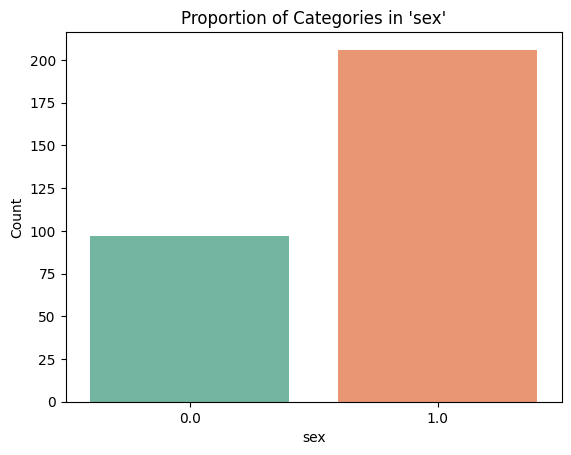

Category Counts and Proportions for 'cp':
     Count  Proportion (%)
cp                        
4.0    144       47.524752
3.0     86       28.382838
2.0     50       16.501650
1.0     23        7.590759




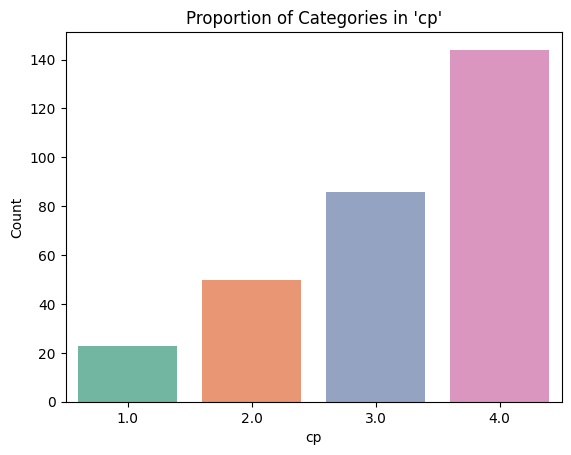

Category Counts and Proportions for 'fbs':
     Count  Proportion (%)
fbs                       
0.0    258       85.148515
1.0     45       14.851485




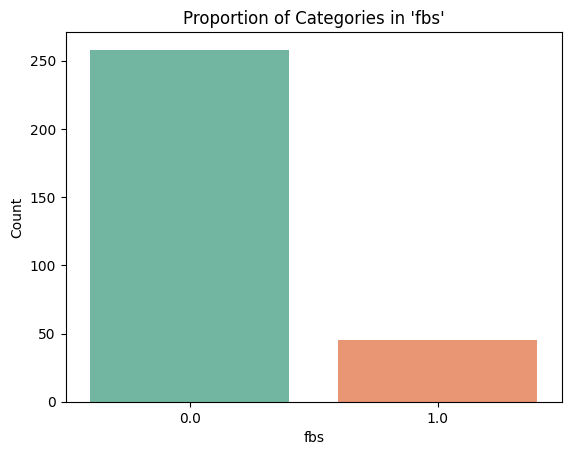

Category Counts and Proportions for 'restecg':
         Count  Proportion (%)
restecg                       
0.0        151       49.834983
2.0        148       48.844884
1.0          4        1.320132




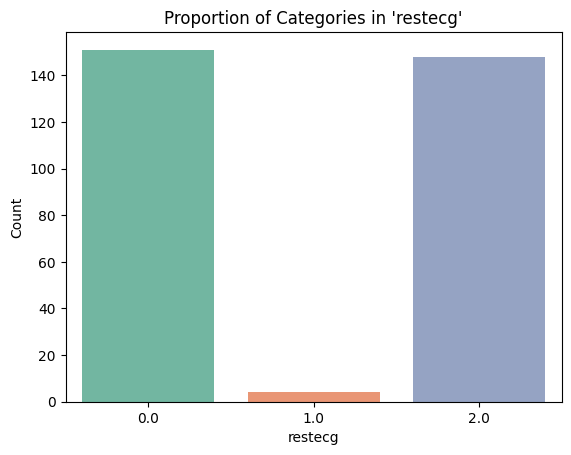

Category Counts and Proportions for 'exang':
       Count  Proportion (%)
exang                       
0.0      204       67.326733
1.0       99       32.673267




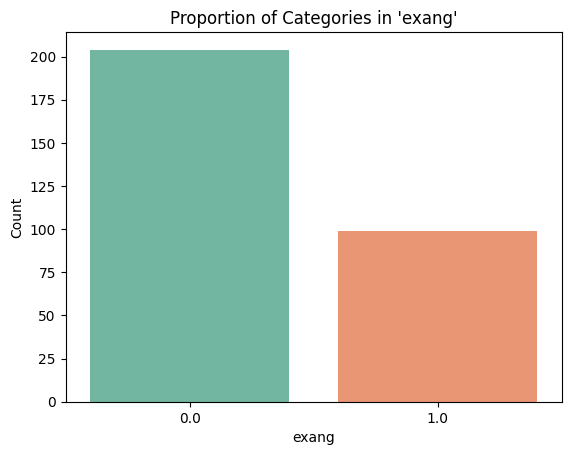

Category Counts and Proportions for 'slope':
       Count  Proportion (%)
slope                       
1.0      142       46.864686
2.0      140       46.204620
3.0       21        6.930693




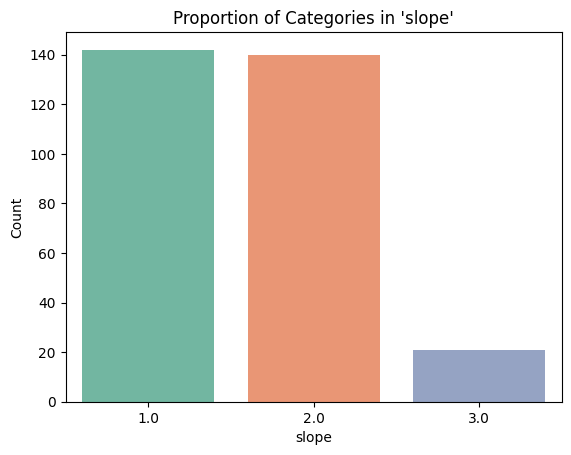

Category Counts and Proportions for 'ca':
    Count  Proportion (%)
ca                       
0     176       58.085809
1      65       21.452145
2      38       12.541254
3      20        6.600660
4       4        1.320132




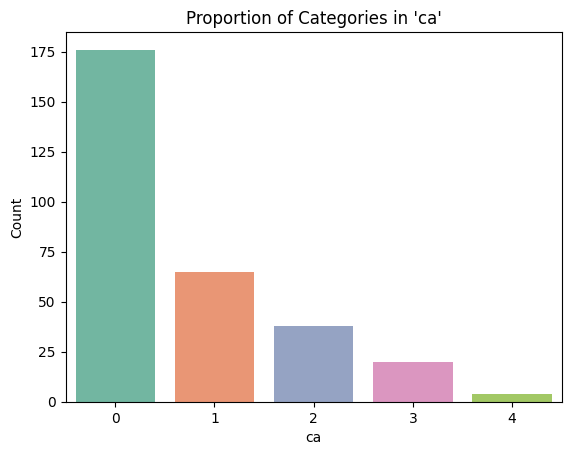

Category Counts and Proportions for 'thal':
      Count  Proportion (%)
thal                       
3       166       54.785479
7       117       38.613861
6        18        5.940594
0         2        0.660066




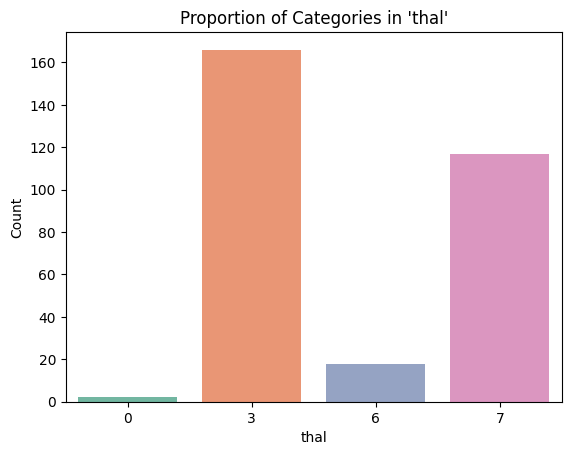

Category Counts and Proportions for 'target':
        Count  Proportion (%)
target                       
0         164       54.125413
1         139       45.874587




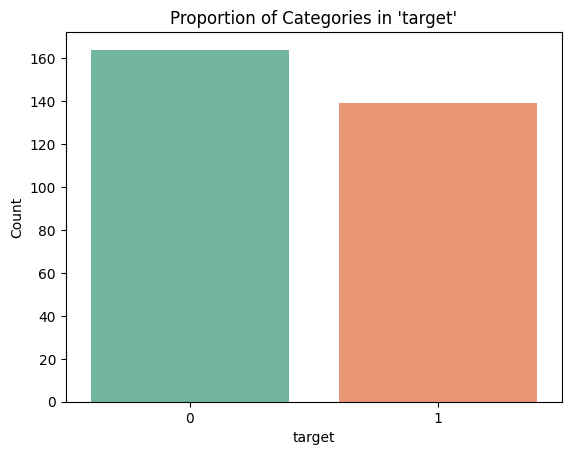

In [683]:
# Now I will call the function on each variable
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

for column in categorical_columns:
    describe_categorical(data, column)

Some comments based on the descriptive analysis for categorical variables: 

I see there is a much higher proportion of male to female than in the general population. The target variable is somewhat well balanced, so ex-ante I have no concerns of needing to oversample or lacking either presence or absence from the target in the sample that will be used to build a predictive model.

Regarding other variables: 

CP: we have the three types of chest pain and asyntomatic.  
FBS: as an indicator of if it is greater than 120 it may be positively associated with HD. As per the article cited above, low values could also be associated so it may be that this variable has low predictive power. 
RESTECG: has 3 values, but 1 is very uncommon. It may be ok to map it to a dummy variable of presence or absence. 
EXANG: two values as expected.
SLOPE: 3 values, 1, 2 and 3. A combination or some of them may be helpful. 3 seems to be somewhat uncommon. 
CA: according to the description it should be 0-3 but I see 0-4. Here we would expect negative correlation.
THAL. Again its strange we have a value of zero since this is against the dictionary labels. Only two observations on that case. 


In [684]:
# Function to explore continuous variables
def describe_continuous(data, column_name):
    """
    Displays descriptive statistics and a boxplot for a continuous variable.

    Parameters:
    - data: Pandas DataFrame containing the data
    - column_name: Name of the continuous column to explore
    """
    # Calculate descriptive statistics
    stats = {
        "Min": data[column_name].min(),
        "Max": data[column_name].max(),
        "Mean": data[column_name].mean(),
        "Median": data[column_name].median()
    }

    # Print descriptive statistics
    print(f"Descriptive Statistics for '{column_name}':")
    for stat, value in stats.items():
        print(f"{stat}: {value}")
    print("\n")

    # Plot a boxplot
    sns.boxplot(x=data[column_name], color="skyblue")
    plt.title(f"Boxplot of '{column_name}'")
    plt.xlabel(column_name)
    plt.show()

    # Plot a histogram
    plt.figure(figsize=(10, 4))
    sns.histplot(data[column_name], kde=True, color="steelblue", bins=20)
    plt.title(f"Histogram of '{column_name}'")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    plt.show()

Descriptive Statistics for 'age':
Min: 29.0
Max: 77.0
Mean: 54.43894389438944
Median: 56.0




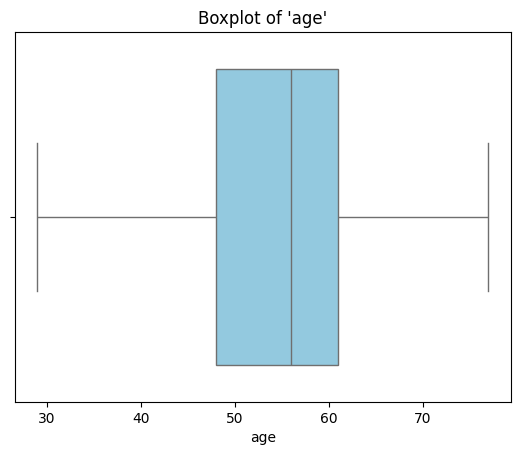

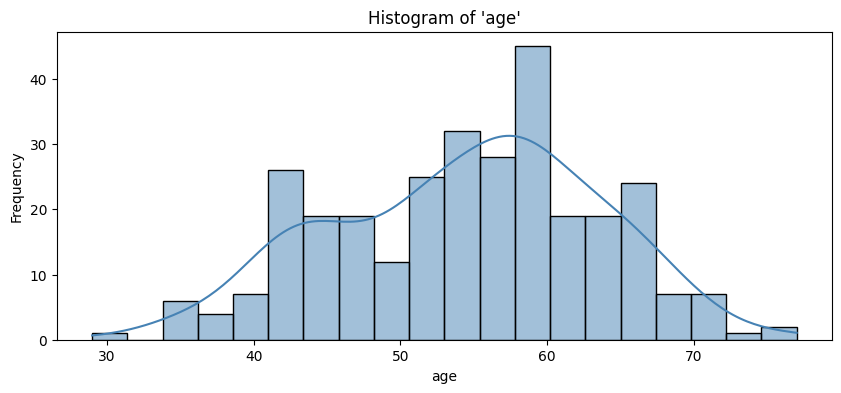

Descriptive Statistics for 'trestbps':
Min: 94.0
Max: 200.0
Mean: 131.68976897689768
Median: 130.0




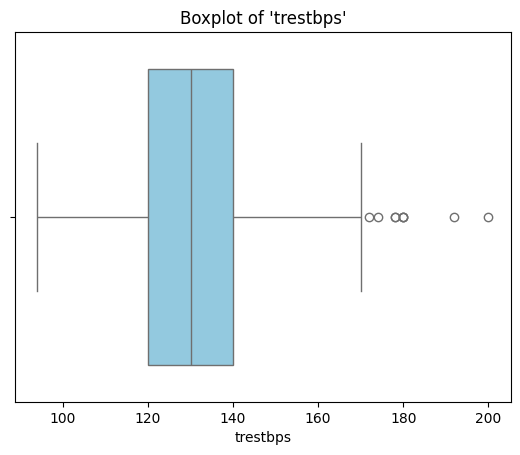

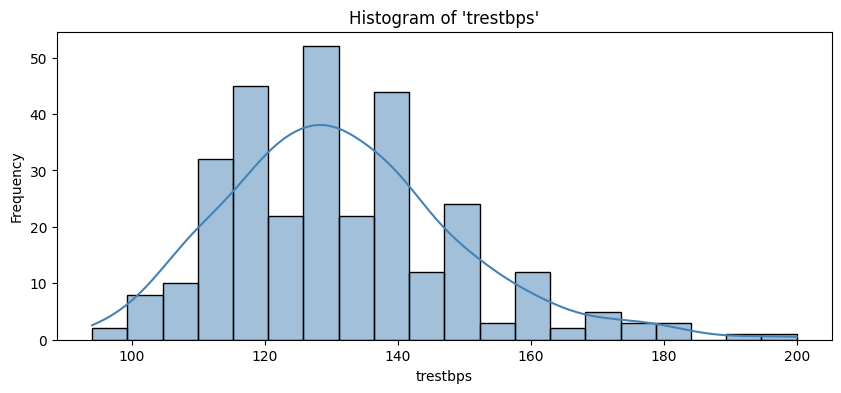

Descriptive Statistics for 'chol':
Min: 126.0
Max: 564.0
Mean: 246.69306930693068
Median: 241.0




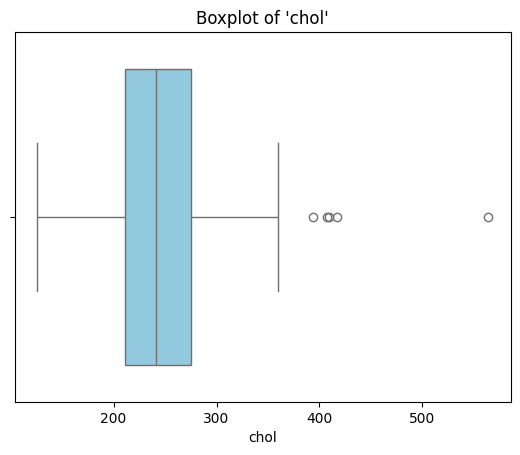

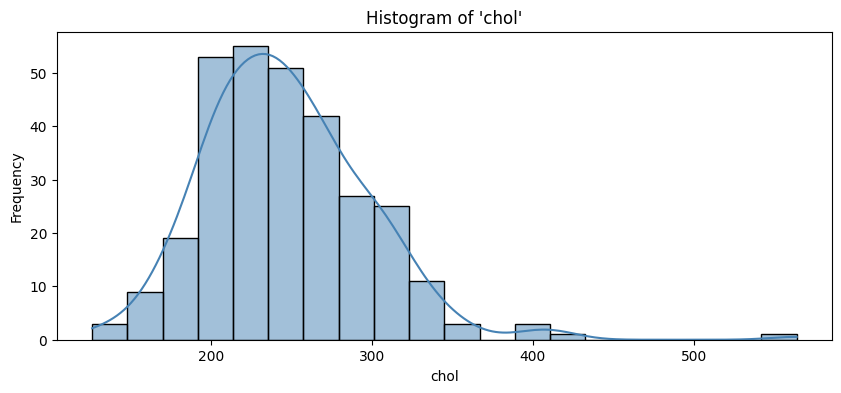

Descriptive Statistics for 'thalach':
Min: 71.0
Max: 202.0
Mean: 149.6072607260726
Median: 153.0




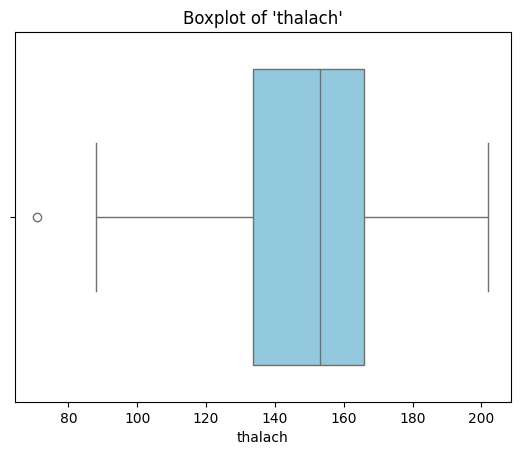

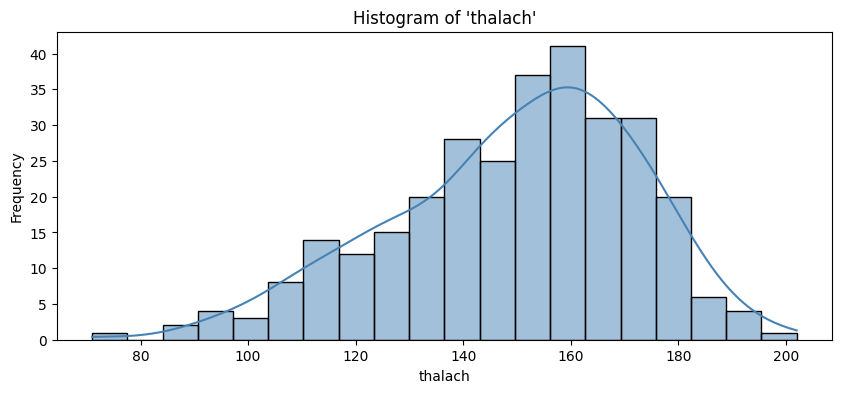

Descriptive Statistics for 'oldpeak':
Min: 0.0
Max: 6.2
Mean: 1.0396039603960396
Median: 0.8




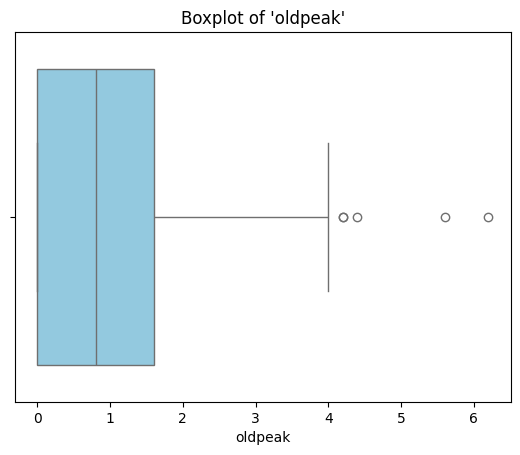

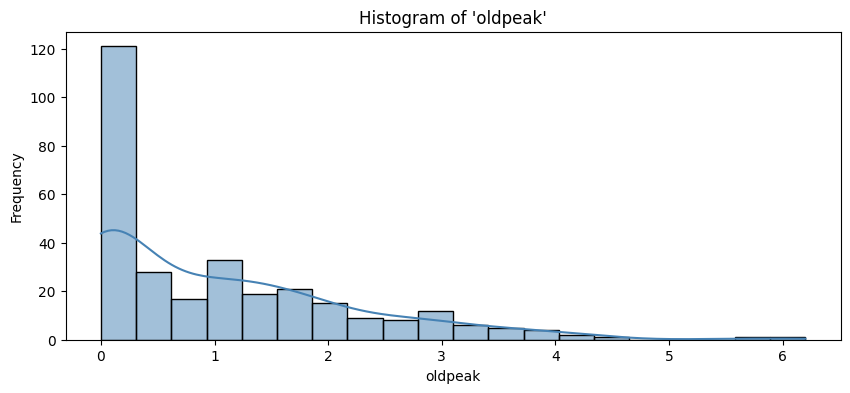

In [685]:
# Now I will call the function on each variable
quantitative_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for column in quantitative_columns:
    describe_continuous(data, column)

Some comments based on the descriptive analysis for continuous variables: 

I see that age is in general higher than the average of the population but this is to be expected given the nature of the dataset. Some of the variables have values that could be considered as outliers and may warrant to investigate if they are correctly measured. An example is the resting blood presure of 200 or cholesterol of 564. A quick research indicates that those values are possible so I will not give any special treatment to them. I would typically investigate those values with subject matter experts to understand if they are expected given the nature of the datasets (for example in this case the high blood presure may correspond to someone in medical emergency).  

Now I want to explore the association of the variables with the target. Before doing this I will split the data at random to maintain a test set that will be used to assess the final model performance. Given the size of the data set I will only maintain a test set of size 20% and will use 5 fold cross validation for variable selection and hyperparameter tunning as needed. 

In [686]:
## Before splitting the data into train and test sets, I will create transformations of the variables to include 
## in the candidate models. 

def preprocess_data(data):
    """
    Preprocesses the dataset by applying transformations.

    Parameters:
    - data: DataFrame containing the raw data.

    Returns:
    - Transformed DataFrame.
    """
    # Create a dummy variable for cp
    data['chest_pain'] = (data['cp'] != 4.0).astype(int) #4 is asymptomatic so im mapping that to 0 

    # Create a dummy variable for restecg (0 vs other values)
    data['resting_ecg'] = (data['restecg'] != 0).astype(int)

    # Create an interaction term between age and sex
    data['age_sex_interaction'] = data['age'] * data['sex']

    # Create an interaction term between restecg and chest_pain
    data['restecg_chest_pain_interaction'] = data['resting_ecg'] * data['chest_pain']

    #create an interaction between chest pain and angina 
    data['chest_pain_angina'] = data['chest_pain'] * data['exang']

    #create an interaction between thalach and chest pain
    data['thalach_chest_pain'] = data['thalach'] * data['chest_pain']

    # Create a dummy variable for slope = 2 vs slope != 2
    data['slope_not_flat'] = (data['slope'] != 2).astype(int)


    # dummy for ca if 0 or not 0 
    data['ca_dummy'] = (data['ca'] != 0).astype(int)

    # "fixed" dummy for ca if 0 or 4 or not 0 or 4 ( this is an attempt to "fix" a possible recording error in the dataset. I based it on the relationship between ca and the target.)
    data['ca_dummy_fixed'] = ((data['ca'] == 0) | (data['ca'] == 4)).astype(int)


    # Perform one-hot encoding for the 'cp' column
    cp_dummies = pd.get_dummies(data['cp'], prefix='cp', drop_first=True).astype(int)

    # Concatenate the dummy variables with the original dataset
    data = pd.concat([data, cp_dummies], axis=1)

    # Verify the changes
    print("Columns after one-hot encoding for 'cp':", cp_dummies.columns)

    # Apply Box-Cox transformation. This may help reduce the impact of outliers for the logistic regression model. I 
    # do not use a boxcox transformation on oldpeak since it has a large number of 0 values. For it, I use a square root transformation as values are all non-negative.     
    data['thalach_boxcox'], _ = boxcox(data['thalach'])
    data['chol_boxcox'], _ = boxcox(data['chol'])
    data['trestbps_boxcox'], _ = boxcox(data['trestbps'])
    data['age_squared'] = data['age'] ** 2
    data['oldpeak_sqrt'] = np.sqrt(data['oldpeak'])

    return data


data = preprocess_data(data)
# Display the first 5 rows of the transformed data to check it was executed correctly
data.head()


Columns after one-hot encoding for 'cp': Index(['cp_2.0', 'cp_3.0', 'cp_4.0'], dtype='object')


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,ca_dummy,ca_dummy_fixed,cp_2.0,cp_3.0,cp_4.0,thalach_boxcox,chol_boxcox,trestbps_boxcox,age_squared,oldpeak_sqrt
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,...,0,1,0,0,0,33091.866784,4.252244,1.394424,3969.0,1.516575
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,...,1,0,0,0,1,15865.778205,4.373017,1.397425,4489.0,1.224745
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,...,1,0,0,0,1,23612.563385,4.241932,1.388045,4489.0,1.612452
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,...,0,1,0,1,0,54198.645317,4.294008,1.390846,1369.0,1.870829
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,...,0,1,1,0,0,44949.834412,4.172650,1.390846,1681.0,1.183216


In [687]:
# Calculate min, max, and mean for all variables
summary_stats = data.describe().T[['min', 'max', 'mean']]

# Display the summary statistics
print("Summary statistics (min, max, mean) for all variables after transformation:")
print(summary_stats)

Summary statistics (min, max, mean) for all variables after transformation:
                                        min           max          mean
age                               29.000000     77.000000     54.438944
sex                                0.000000      1.000000      0.679868
cp                                 1.000000      4.000000      3.158416
trestbps                          94.000000    200.000000    131.689769
chol                             126.000000    564.000000    246.693069
fbs                                0.000000      1.000000      0.148515
restecg                            0.000000      2.000000      0.990099
thalach                           71.000000    202.000000    149.607261
exang                              0.000000      1.000000      0.326733
oldpeak                            0.000000      6.200000      1.039604
slope                              1.000000      3.000000      1.600660
ca                                 0.000000      4.000000   

In [688]:
# Unique values in 'cp' and 'ca'
print(data['cp'].unique())
print(data['ca'].unique())

[1. 4. 3. 2.]
[0 3 2 1 4]


In [689]:
# Split the data into train and test sets. I use 80% of the data for training and 20% for testing. 
# please keep the random state fixed for reproducibility at 1001. 
train_data, test_data = train_test_split(data, test_size=0.20, random_state=1001)

# Display the sizes of the splits
print(f"Train set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")



Train set size: 242
Test set size: 61


In [690]:
# now I will do the k-fold cross validation.
# Initialize KFold with 5 splits. The shuffle parameter is set to True to randomize the data before splitting even if the data does not seem to follow a specific order.
kf = KFold(n_splits=5, shuffle=True, random_state=1001)

In [691]:
# Functions to check association between the categorical variables and the target variable. 
def association_categorical(train_fold, column_name, target_name="target"):
    """
    Analyze a categorical variable by plotting its distribution against the
    the proportion of target=1.

    Parameters:
    - train_fold: Pandas DataFrame containing the training data for the fold.
    - column_name: Name of the categorical column to analyze.
    - target_name: Name of the target column (default is 'target' for simplicity).
    """
    # Calculate the proportion of target=1 for each category
    category_summary = train_fold.groupby(column_name)[target_name].mean()

    # Count the occurrences of each category
    counts = train_fold[column_name].value_counts()

    # Create a bar plot
    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values, palette="Set2", hue=counts.index)
    plt.title(f"Distribution of '{column_name}' with Target=1 Proportion")
    plt.xlabel(column_name)
    plt.ylabel("Count")

    # Add labels for the proportion of target=1
    for i, category in enumerate(counts.index):
        proportion = category_summary.get(category, 0)
        plt.text(i, counts[category], f"{proportion:.2f}", ha="center", va="bottom", fontsize=10)

    plt.show()



In [692]:
# Functions to check correlation between the continuous variables and the target variable. 
def association_continuous(train_fold, column_name, target_name="target"):
    """
    Analyze a continuous variable by calculating its correlation with the target
    and plotting a scatter plot with a regression line.

    Parameters:
    - train_fold: Pandas DataFrame containing the training data for the fold.
    - column_name: Name of the continuous column to analyze.
    - target_name: Name of the target column (default is 'target' for simplicity).
    """
    # Calculate the correlation with the target
    correlation = train_fold[[column_name, target_name]].corr().iloc[0, 1]

    # Print the correlation
    print(f"Correlation between '{column_name}' and '{target_name}': {correlation:.2f}")

    # Create a scatter plot with a regression line
    plt.figure(figsize=(8, 5))
    sns.regplot(x=column_name, y=target_name, data=train_fold, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    plt.title(f"Scatter Plot of '{column_name}' vs '{target_name}'")
    plt.xlabel(column_name)
    plt.ylabel(target_name)
    plt.show()

Fold 1:
  Training set size: 193
  Validation set size: 49
Analyzing categorical variable: sex


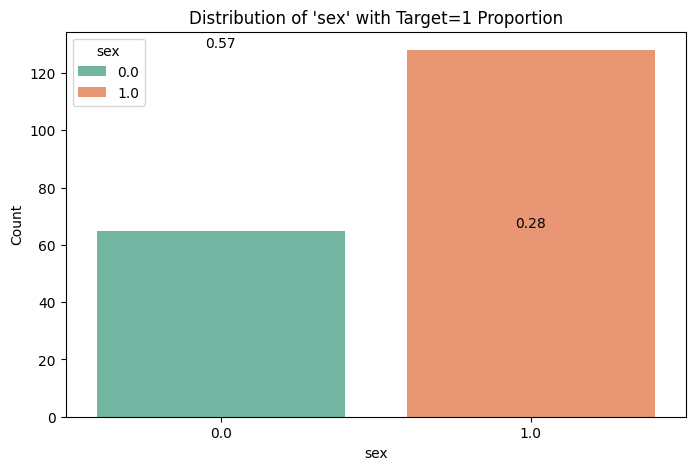

Analyzing categorical variable: cp


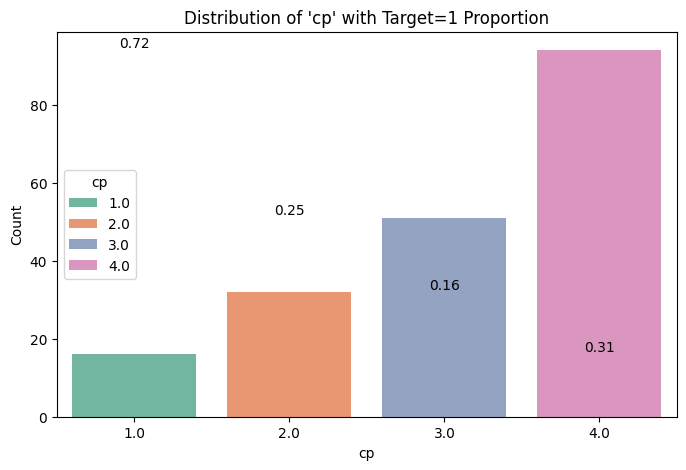

Analyzing categorical variable: fbs


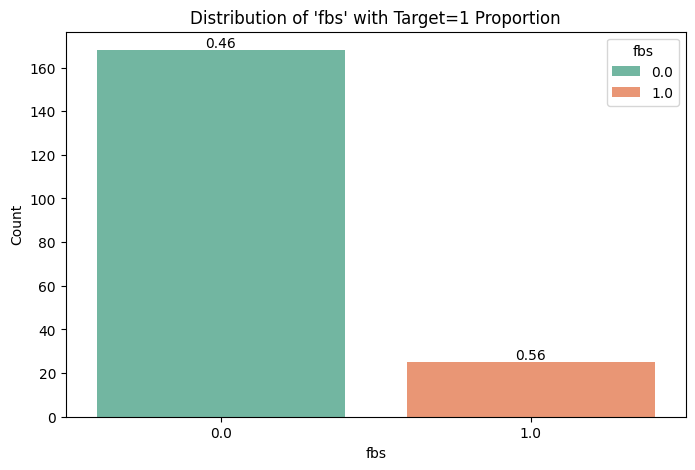

Analyzing categorical variable: restecg


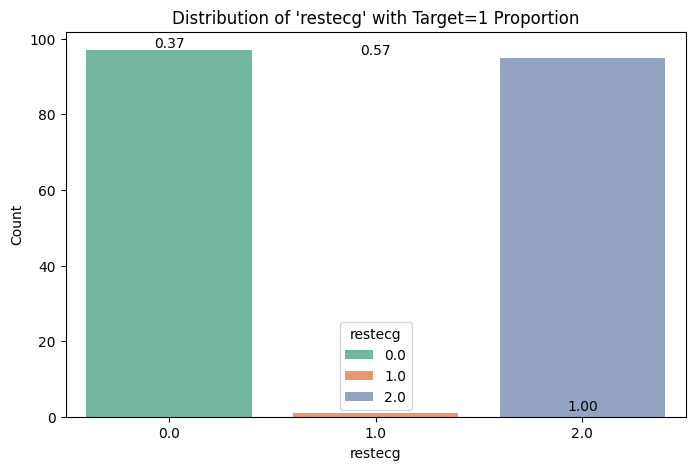

Analyzing categorical variable: exang


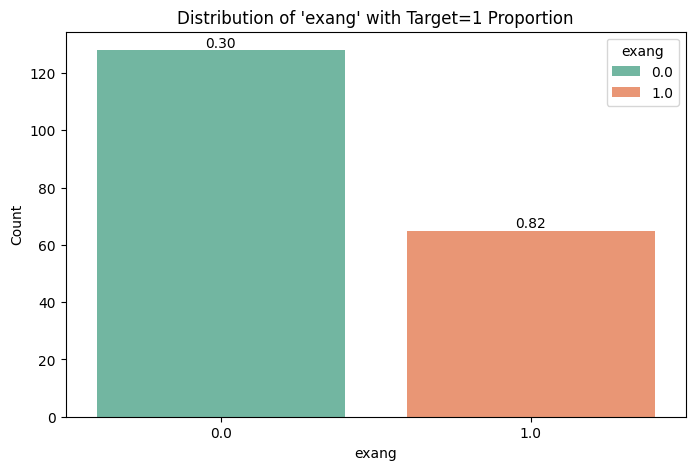

Analyzing categorical variable: slope


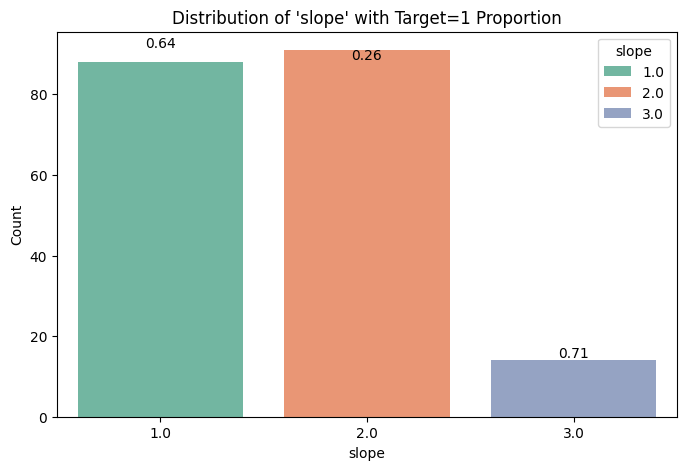

Analyzing categorical variable: ca


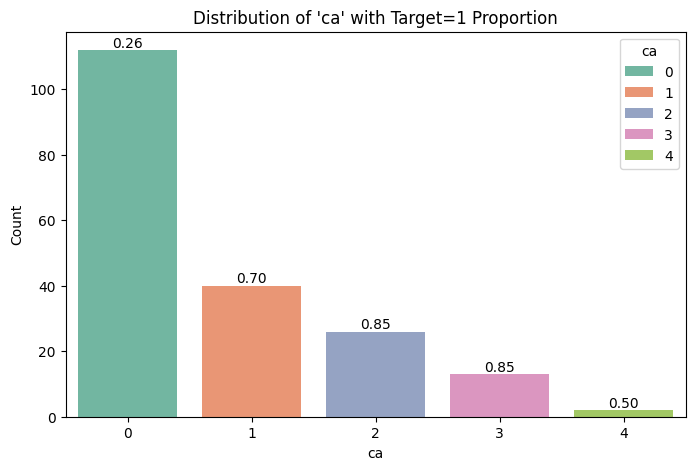

Analyzing categorical variable: thal


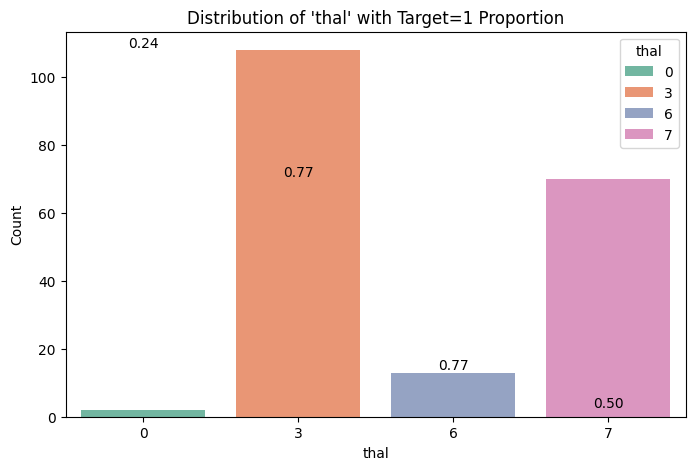

Analyzing continuous variable: age
Correlation between 'age' and 'target': 0.30


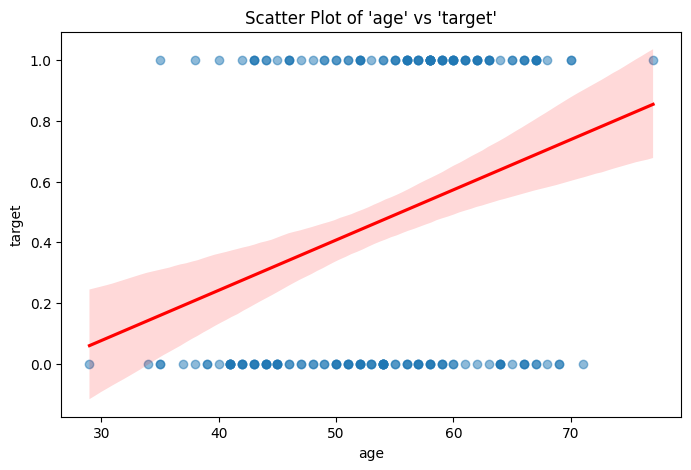

Analyzing continuous variable: trestbps
Correlation between 'trestbps' and 'target': 0.23


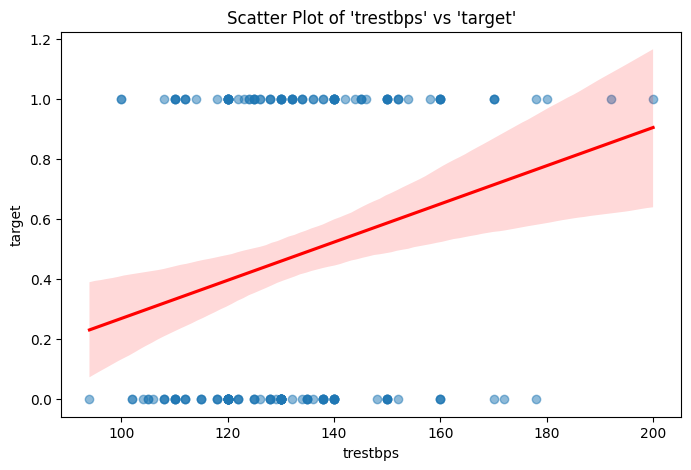

Analyzing continuous variable: chol
Correlation between 'chol' and 'target': 0.14


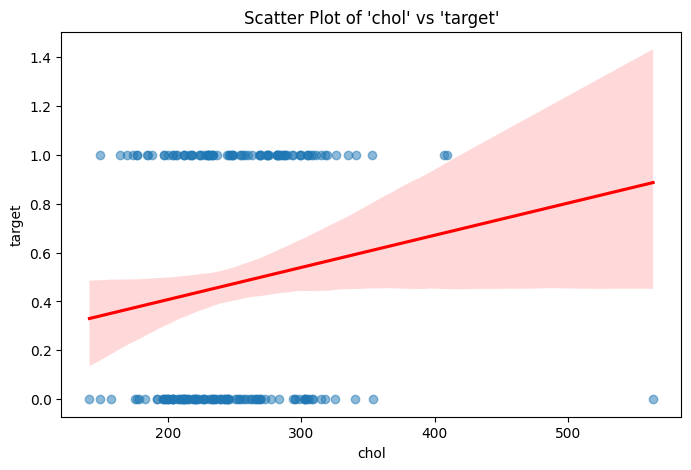

Analyzing continuous variable: thalach
Correlation between 'thalach' and 'target': -0.38


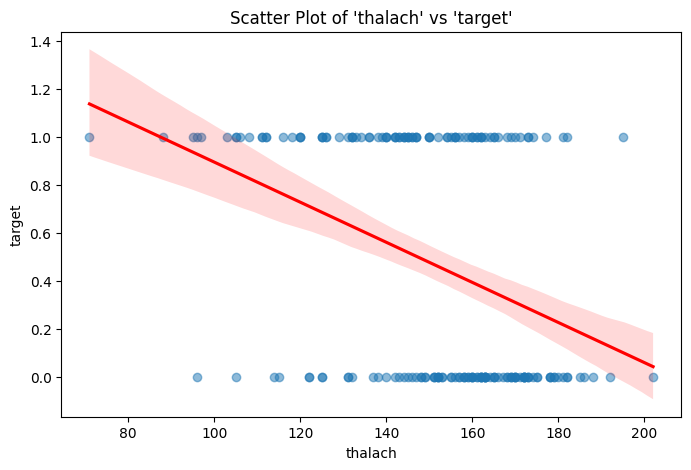

Analyzing continuous variable: oldpeak
Correlation between 'oldpeak' and 'target': 0.42


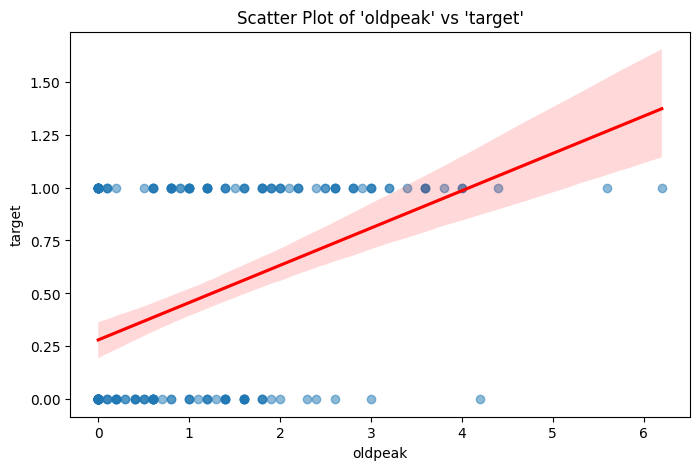

Fold 2:
  Training set size: 193
  Validation set size: 49
Analyzing categorical variable: sex


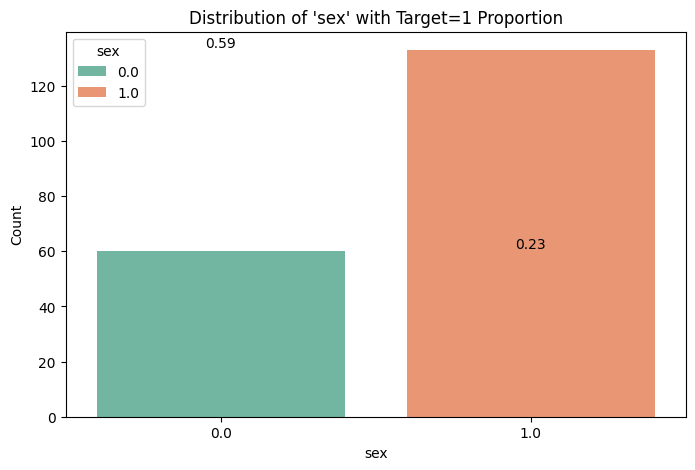

Analyzing categorical variable: cp


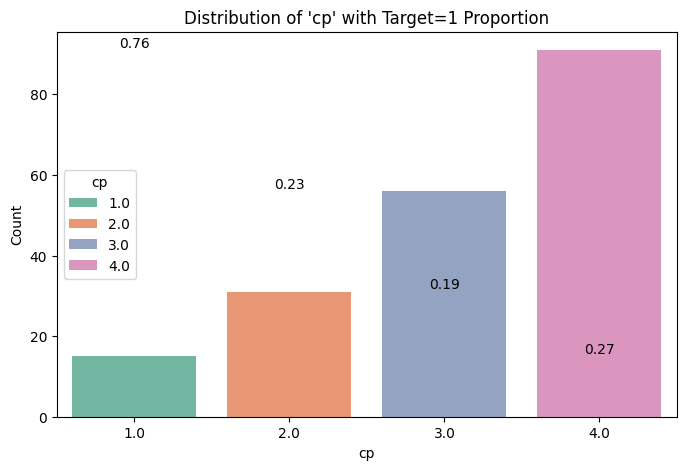

Analyzing categorical variable: fbs


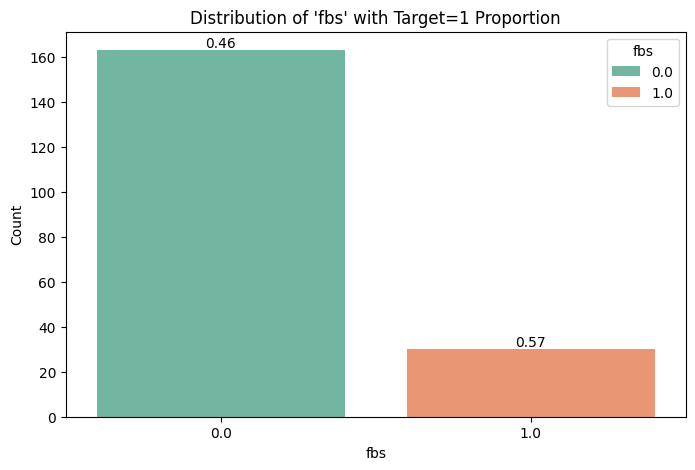

Analyzing categorical variable: restecg


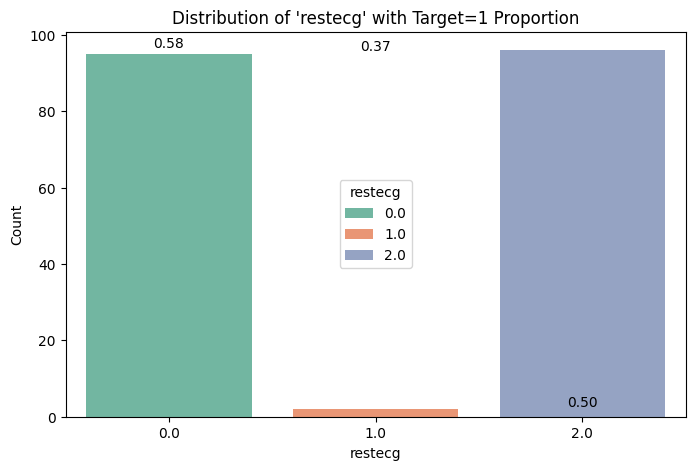

Analyzing categorical variable: exang


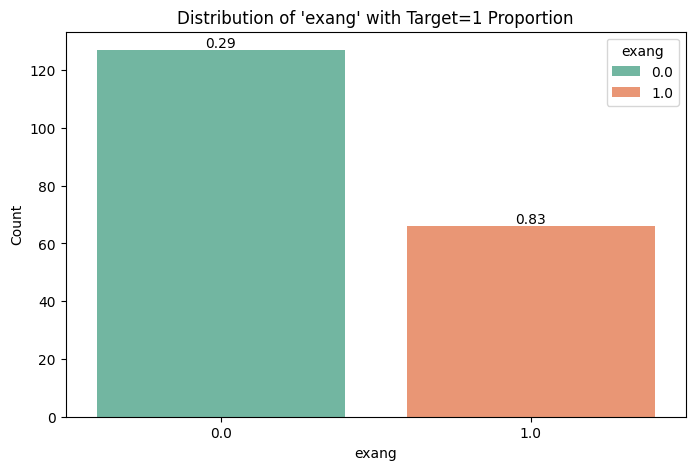

Analyzing categorical variable: slope


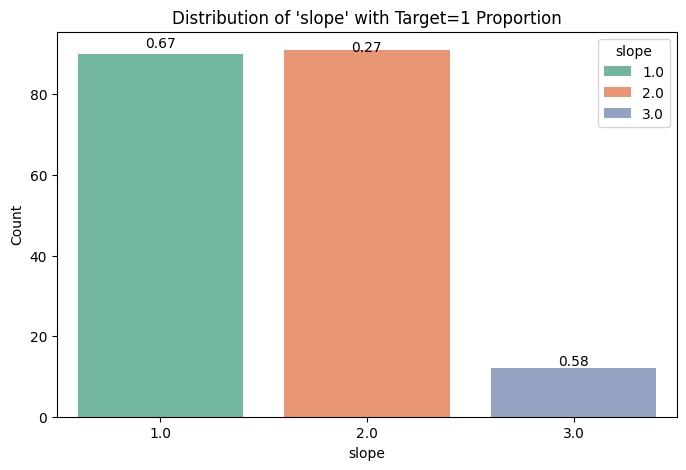

Analyzing categorical variable: ca


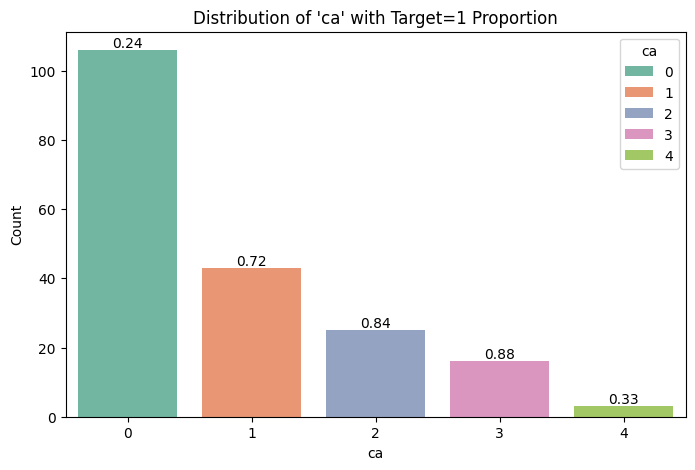

Analyzing categorical variable: thal


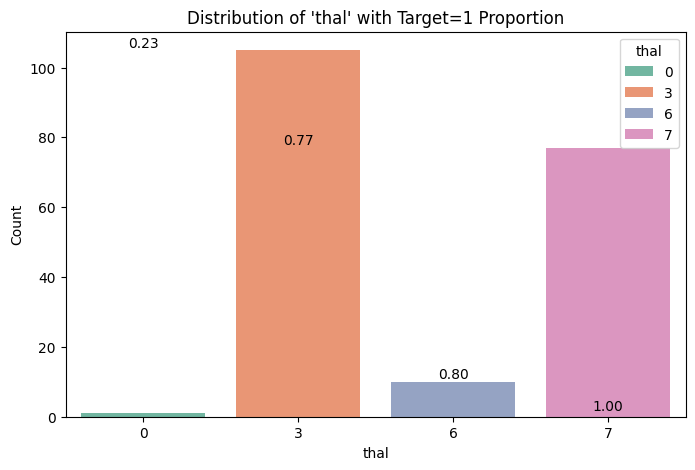

Analyzing continuous variable: age
Correlation between 'age' and 'target': 0.26


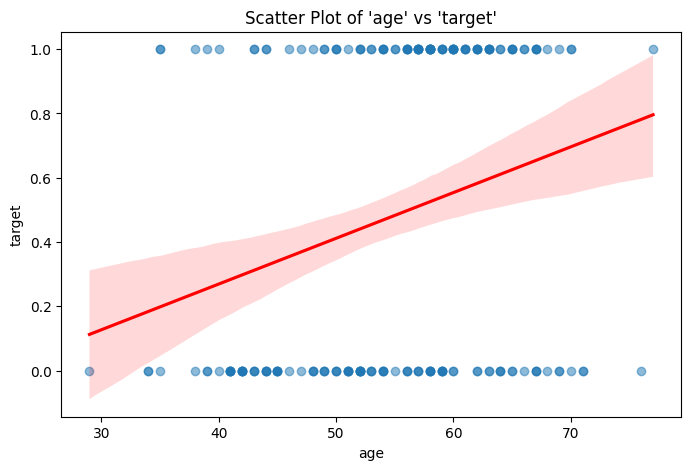

Analyzing continuous variable: trestbps
Correlation between 'trestbps' and 'target': 0.19


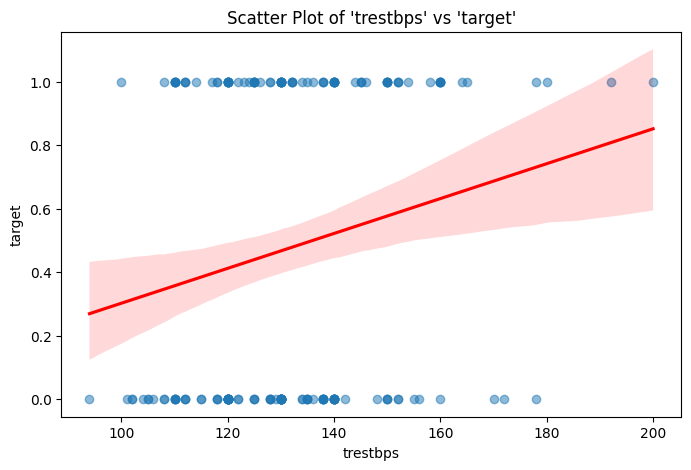

Analyzing continuous variable: chol
Correlation between 'chol' and 'target': 0.10


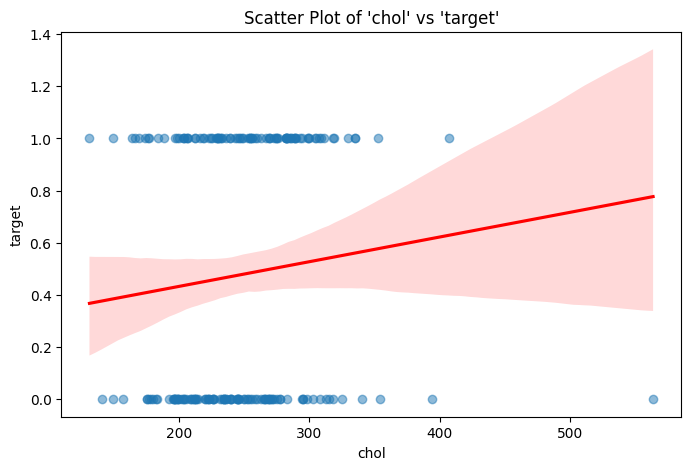

Analyzing continuous variable: thalach
Correlation between 'thalach' and 'target': -0.42


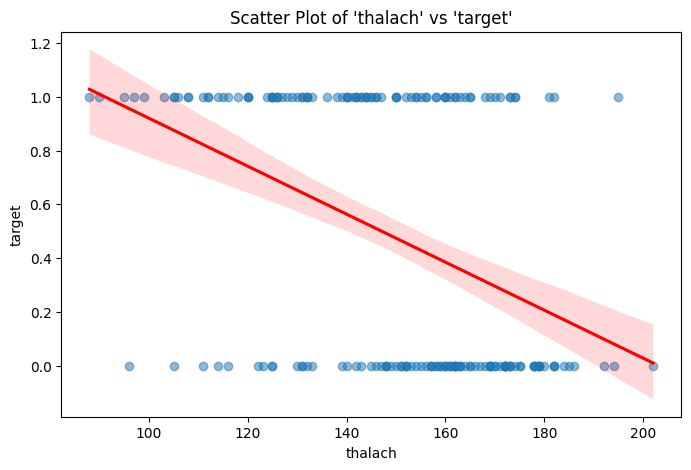

Analyzing continuous variable: oldpeak
Correlation between 'oldpeak' and 'target': 0.44


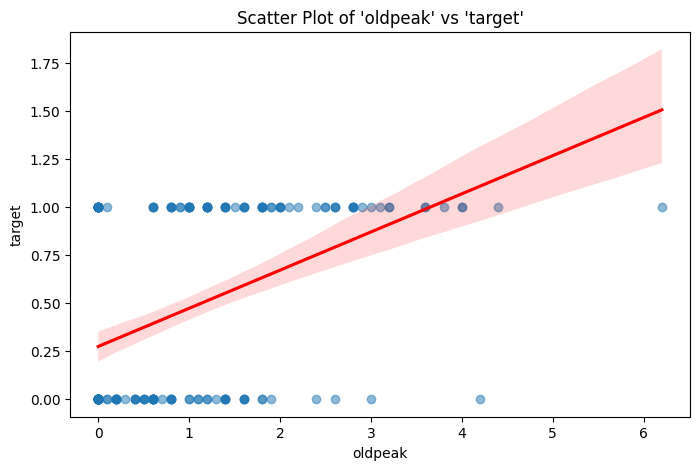

Fold 3:
  Training set size: 194
  Validation set size: 48
Analyzing categorical variable: sex


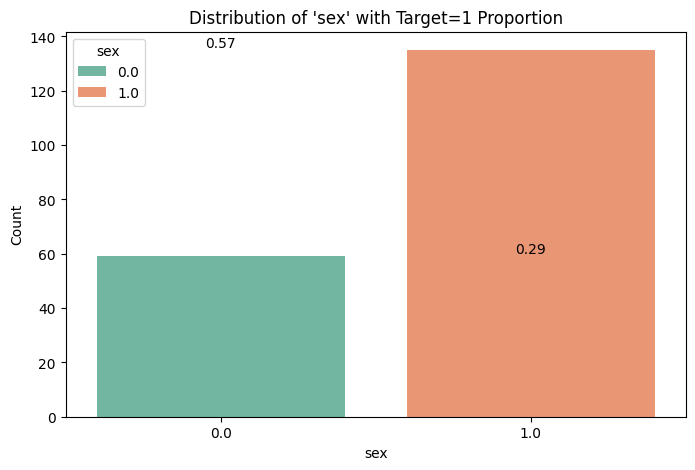

Analyzing categorical variable: cp


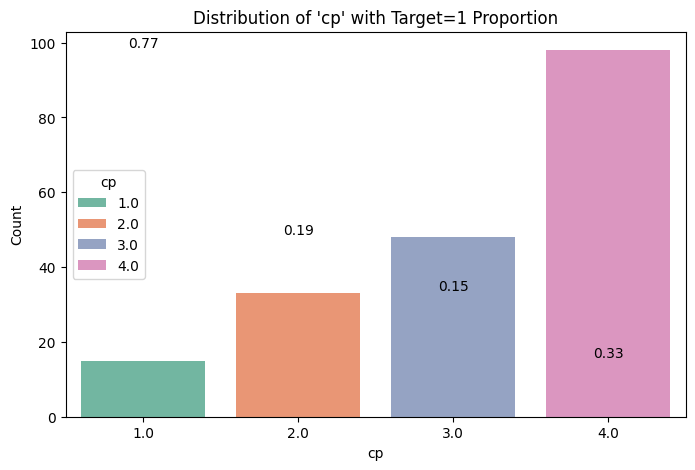

Analyzing categorical variable: fbs


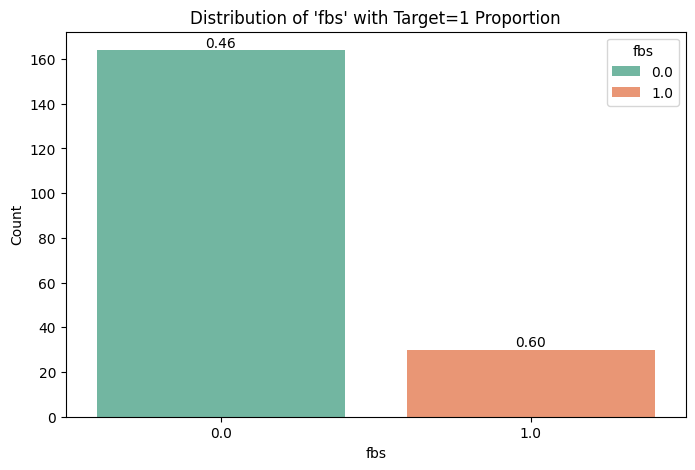

Analyzing categorical variable: restecg


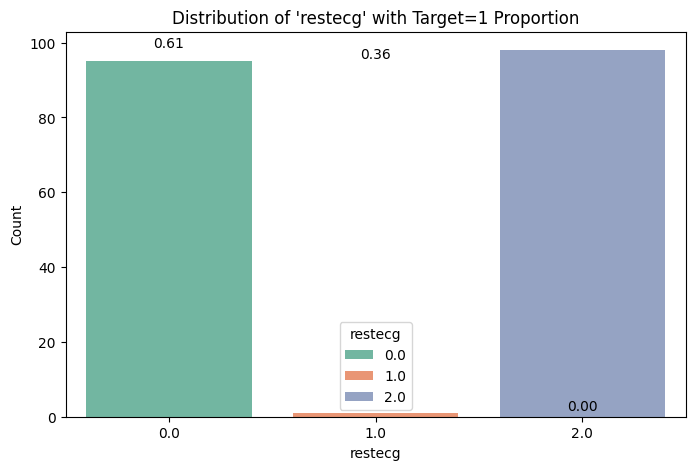

Analyzing categorical variable: exang


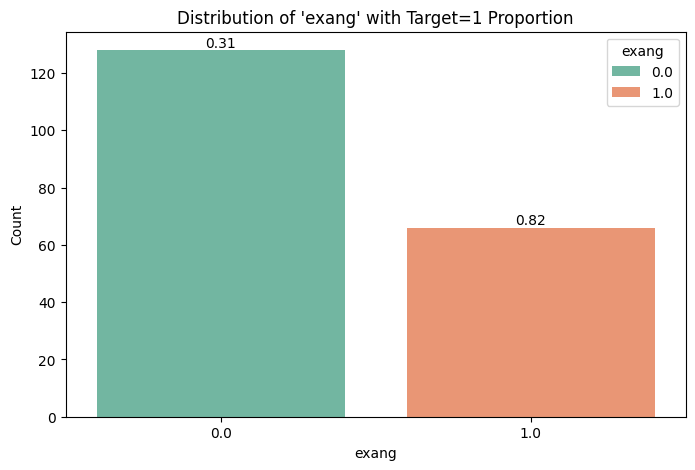

Analyzing categorical variable: slope


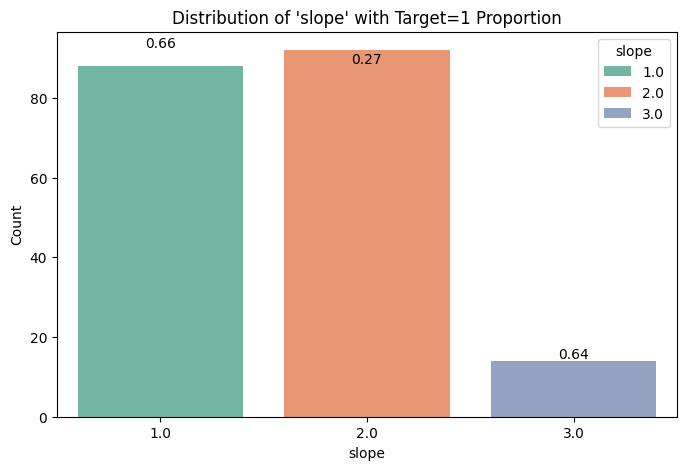

Analyzing categorical variable: ca


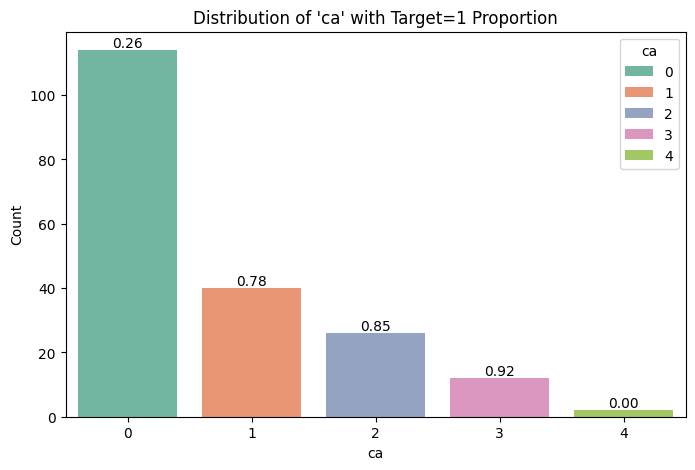

Analyzing categorical variable: thal


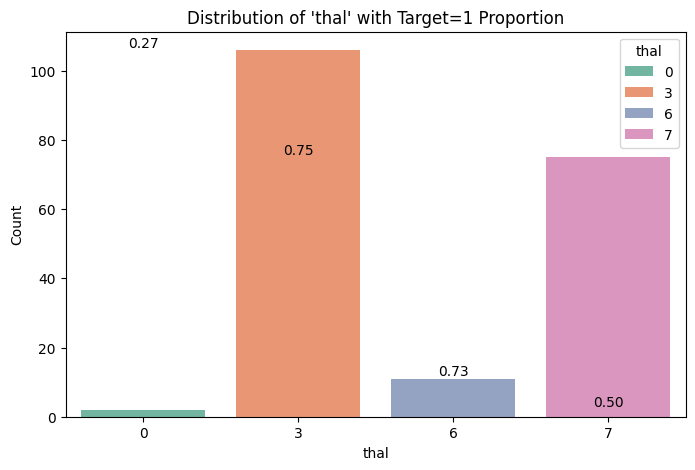

Analyzing continuous variable: age
Correlation between 'age' and 'target': 0.23


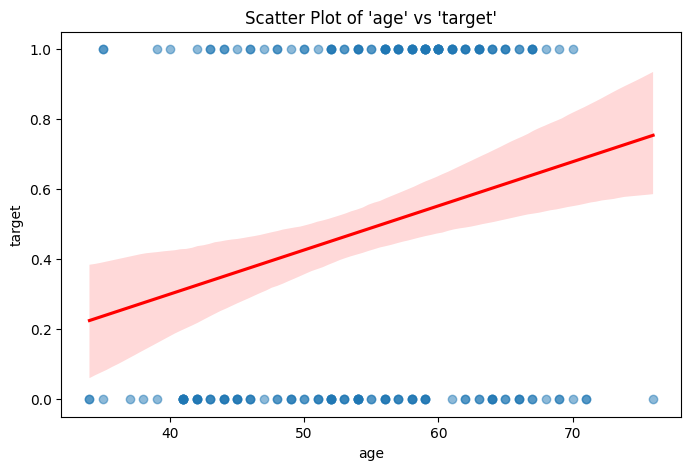

Analyzing continuous variable: trestbps
Correlation between 'trestbps' and 'target': 0.15


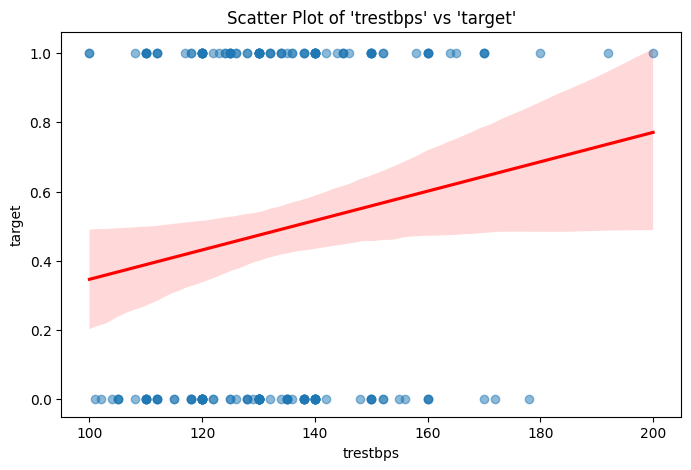

Analyzing continuous variable: chol
Correlation between 'chol' and 'target': 0.08


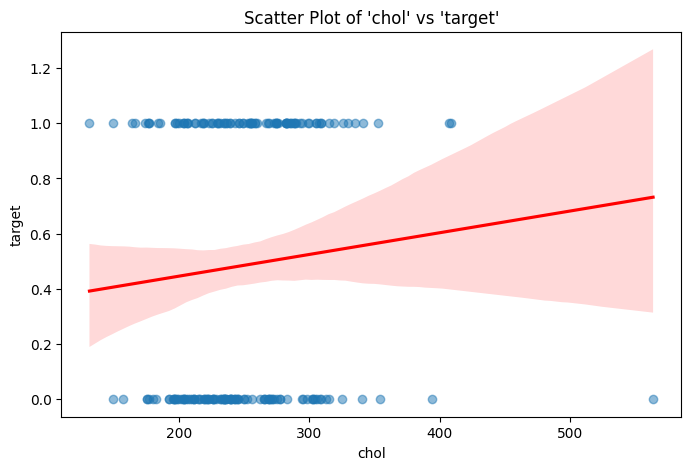

Analyzing continuous variable: thalach
Correlation between 'thalach' and 'target': -0.44


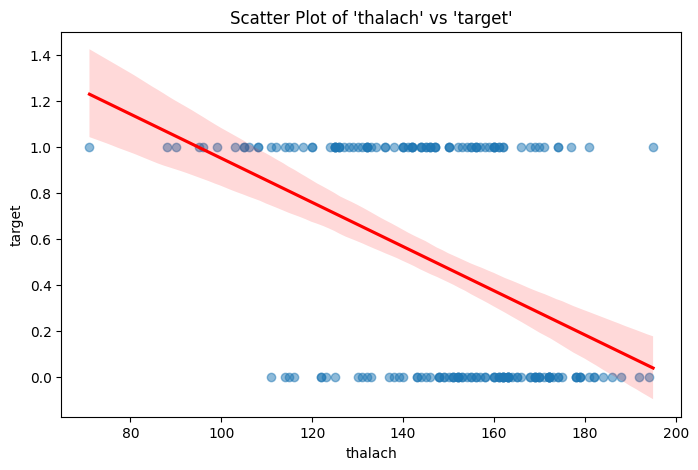

Analyzing continuous variable: oldpeak
Correlation between 'oldpeak' and 'target': 0.42


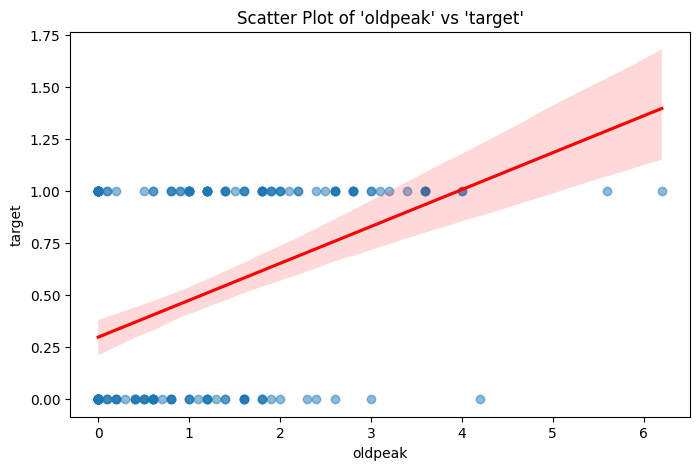

Fold 4:
  Training set size: 194
  Validation set size: 48
Analyzing categorical variable: sex


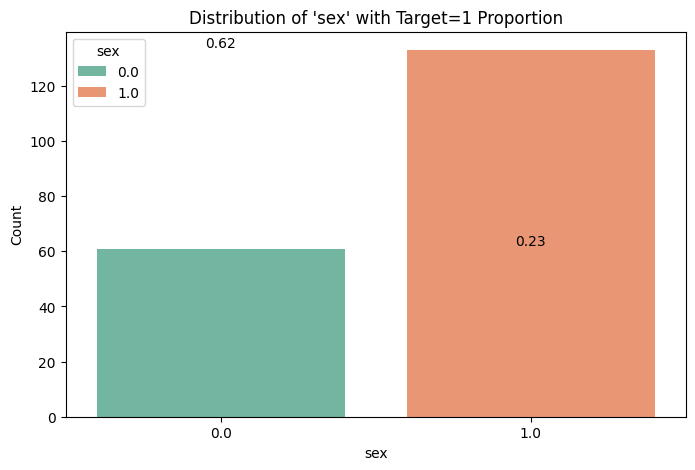

Analyzing categorical variable: cp


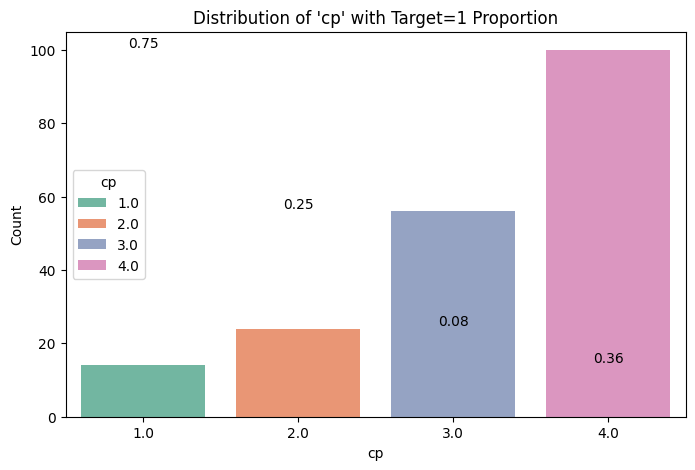

Analyzing categorical variable: fbs


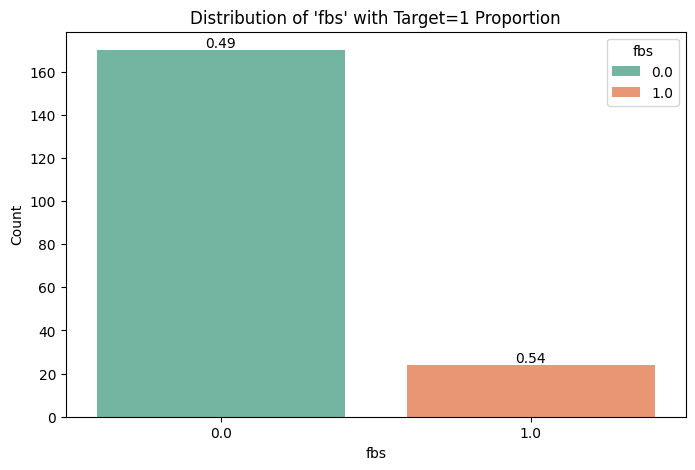

Analyzing categorical variable: restecg


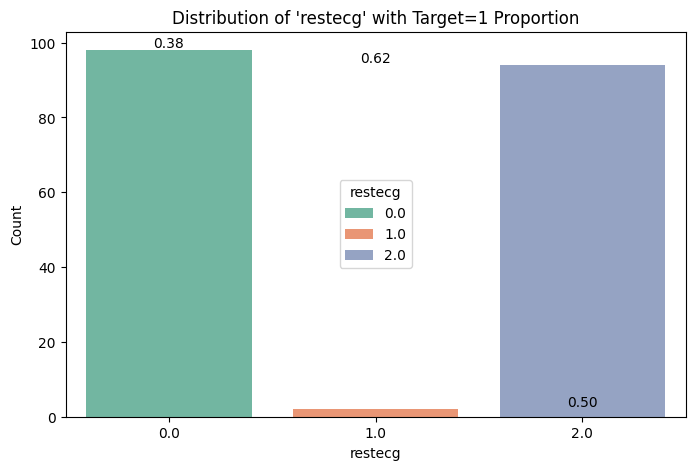

Analyzing categorical variable: exang


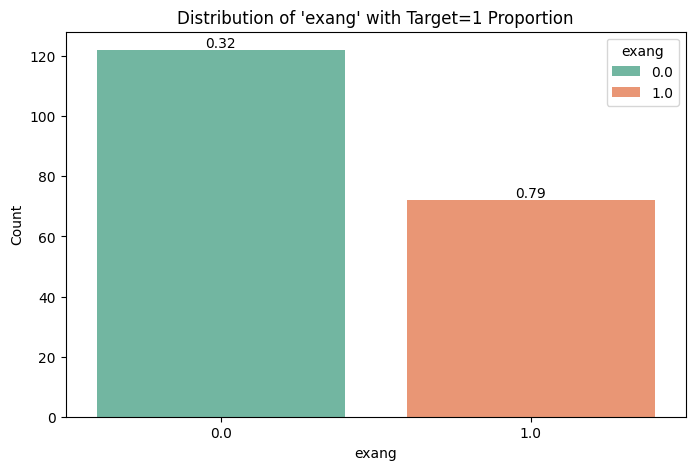

Analyzing categorical variable: slope


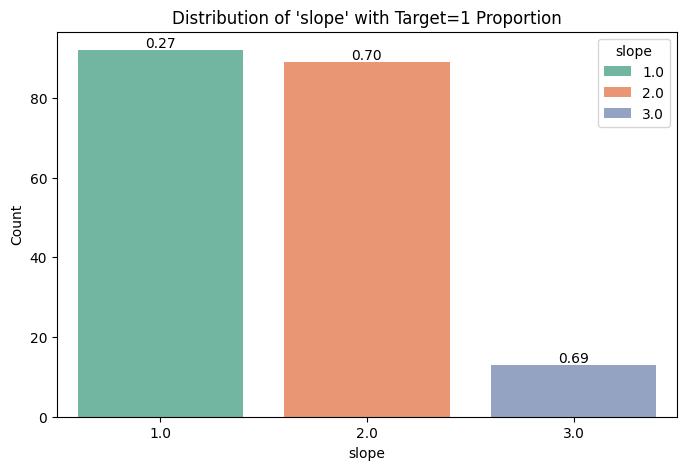

Analyzing categorical variable: ca


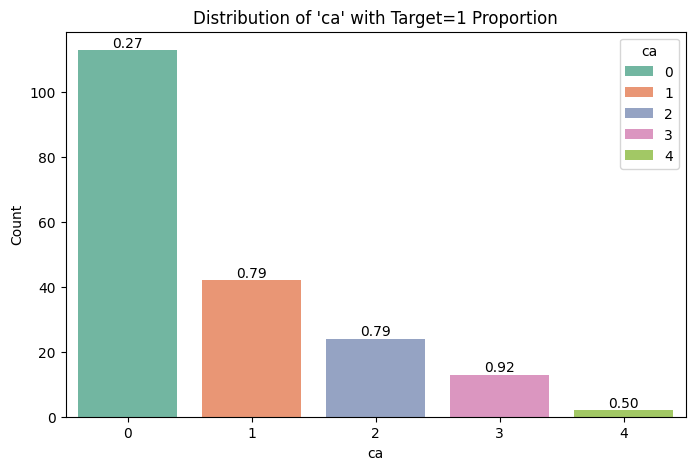

Analyzing categorical variable: thal


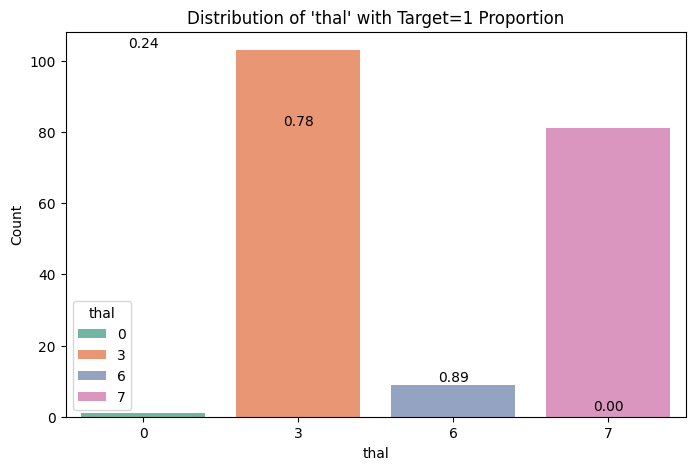

Analyzing continuous variable: age
Correlation between 'age' and 'target': 0.21


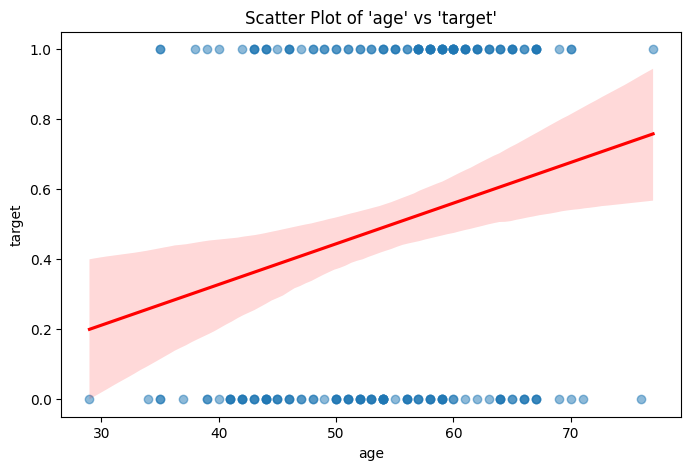

Analyzing continuous variable: trestbps
Correlation between 'trestbps' and 'target': 0.17


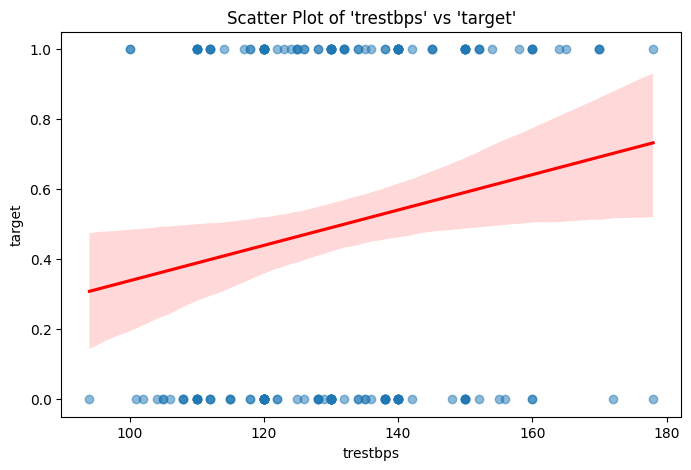

Analyzing continuous variable: chol
Correlation between 'chol' and 'target': 0.12


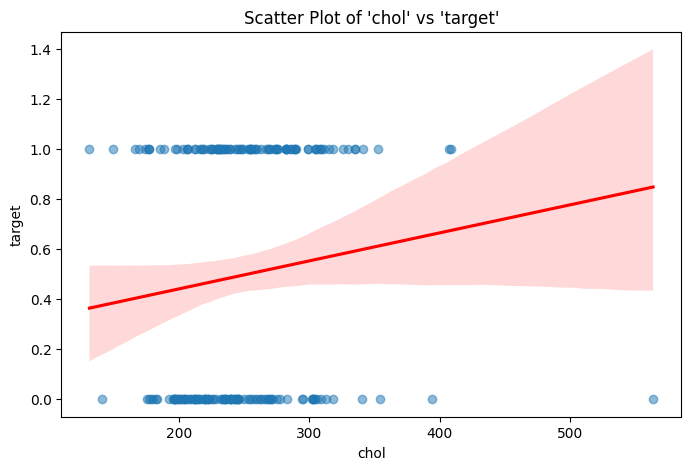

Analyzing continuous variable: thalach
Correlation between 'thalach' and 'target': -0.41


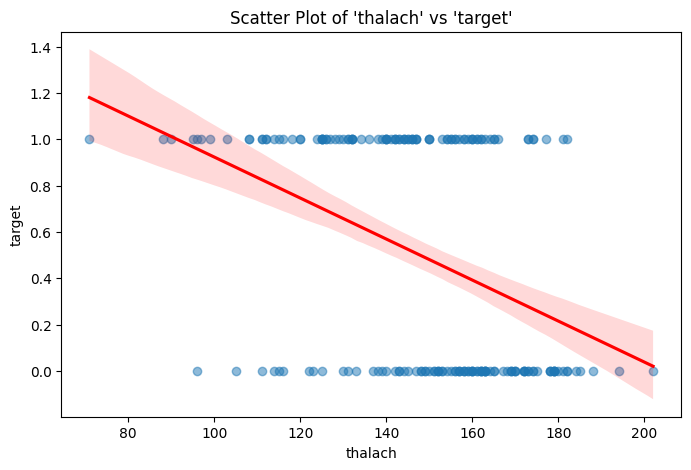

Analyzing continuous variable: oldpeak
Correlation between 'oldpeak' and 'target': 0.47


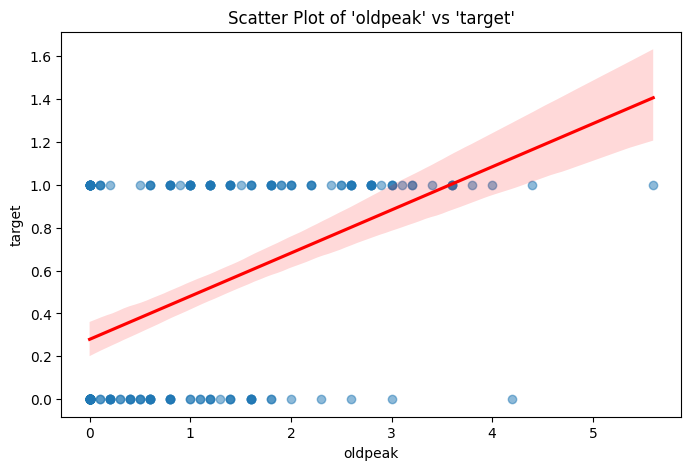

Fold 5:
  Training set size: 194
  Validation set size: 48
Analyzing categorical variable: sex


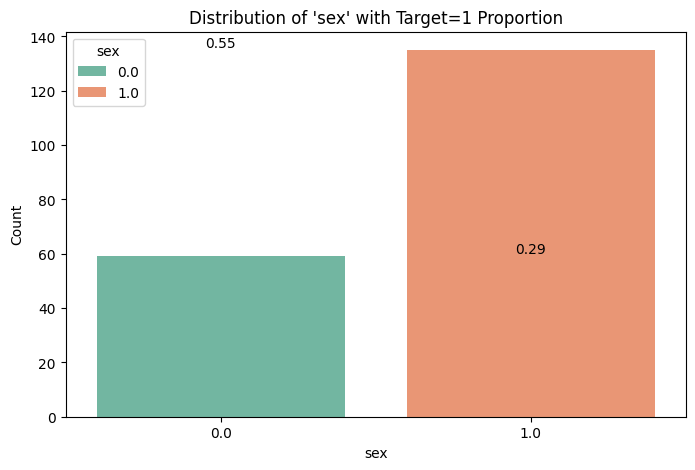

Analyzing categorical variable: cp


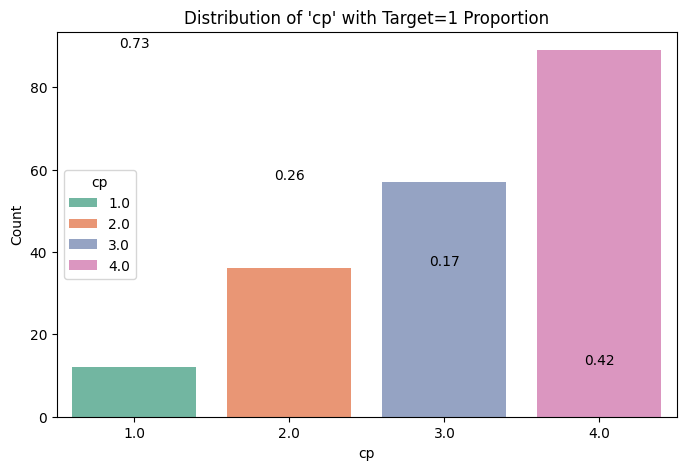

Analyzing categorical variable: fbs


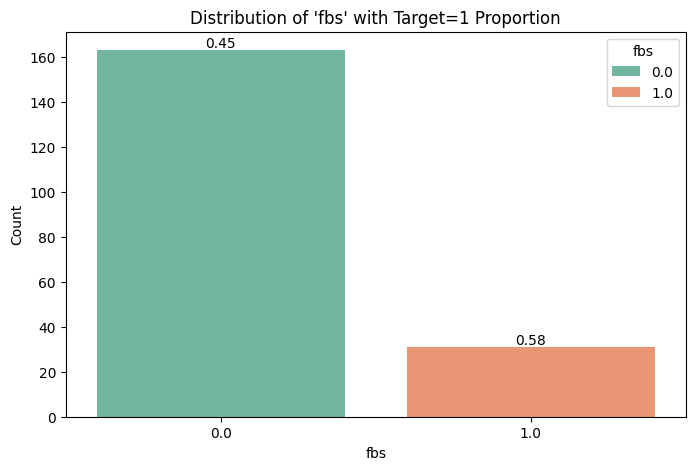

Analyzing categorical variable: restecg


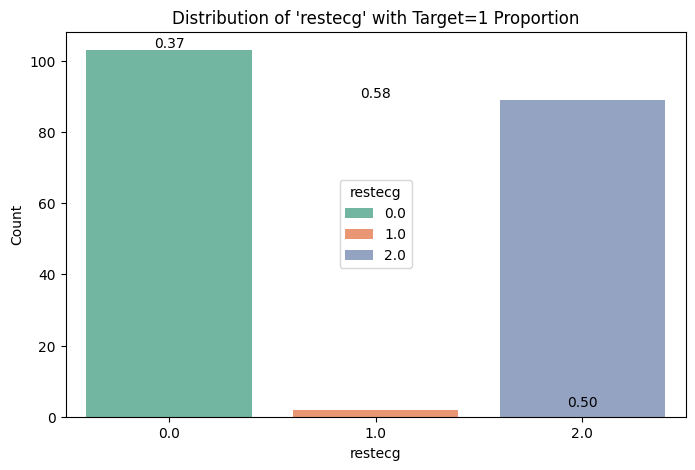

Analyzing categorical variable: exang


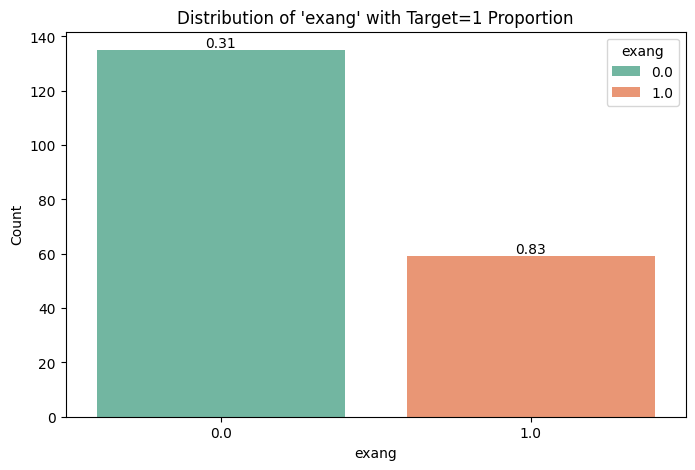

Analyzing categorical variable: slope


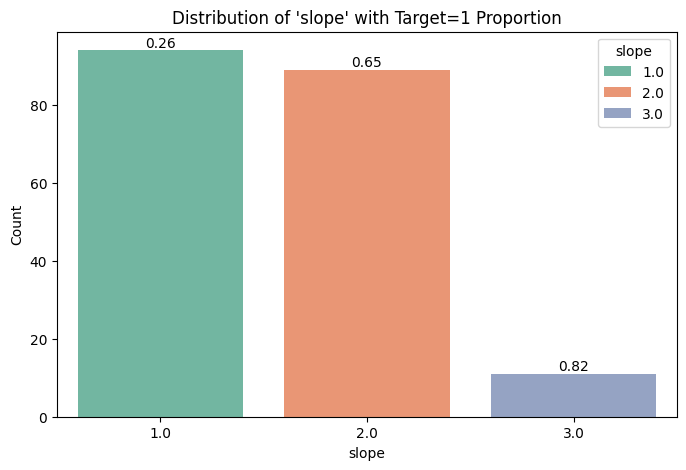

Analyzing categorical variable: ca


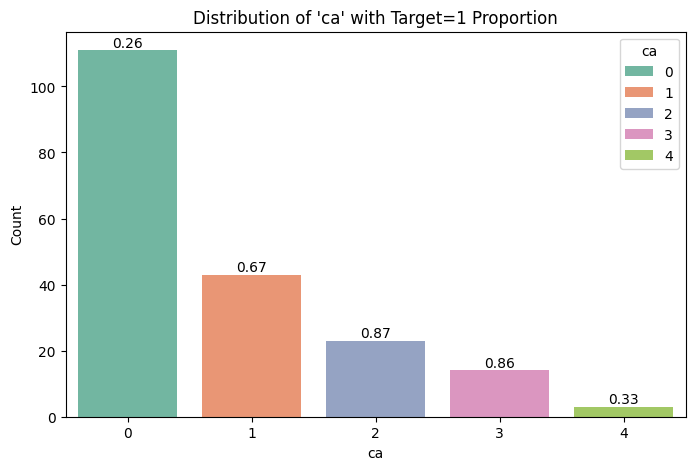

Analyzing categorical variable: thal


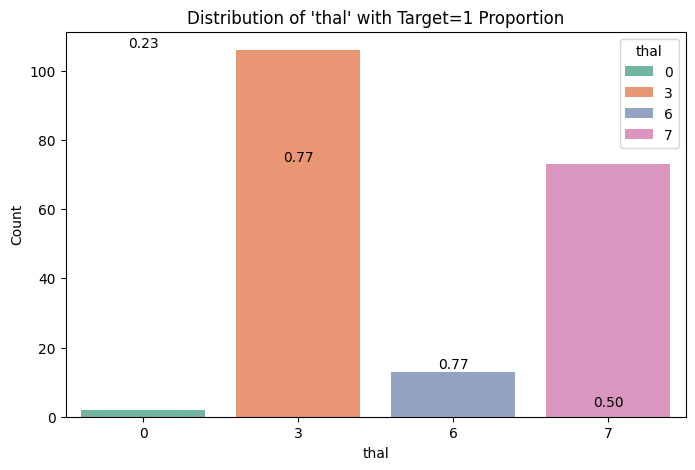

Analyzing continuous variable: age
Correlation between 'age' and 'target': 0.27


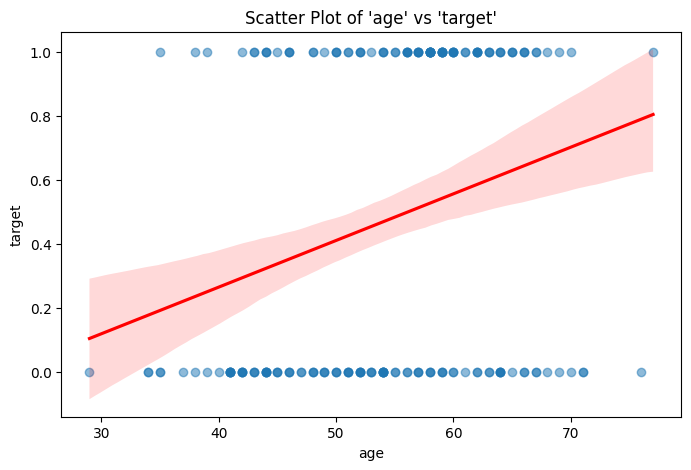

Analyzing continuous variable: trestbps
Correlation between 'trestbps' and 'target': 0.24


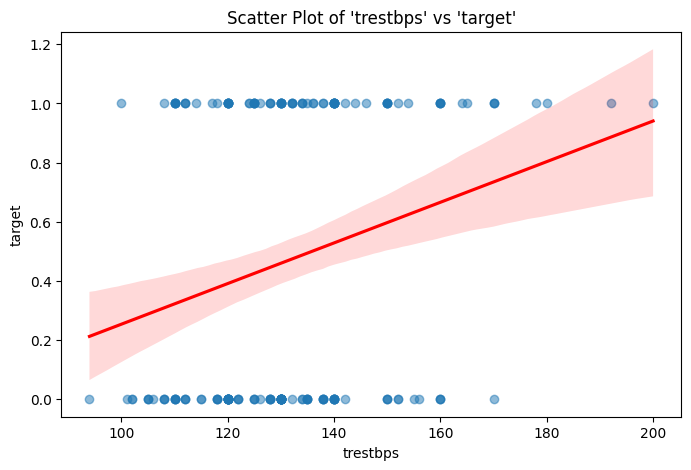

Analyzing continuous variable: chol
Correlation between 'chol' and 'target': 0.13


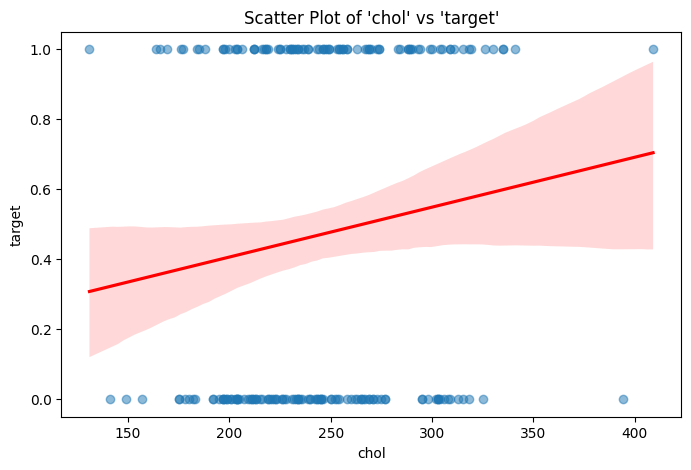

Analyzing continuous variable: thalach
Correlation between 'thalach' and 'target': -0.37


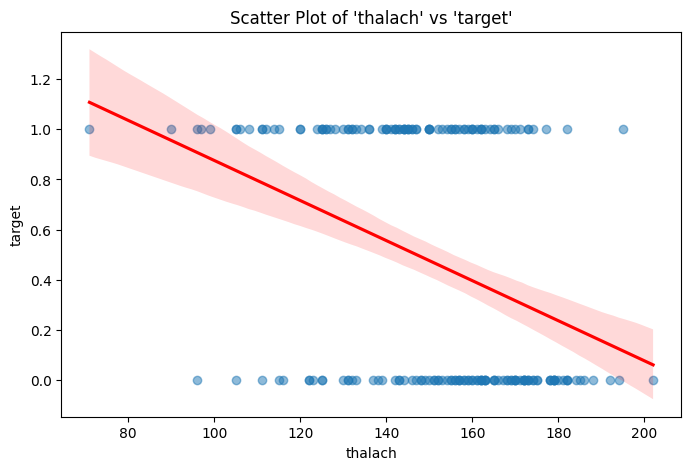

Analyzing continuous variable: oldpeak
Correlation between 'oldpeak' and 'target': 0.48


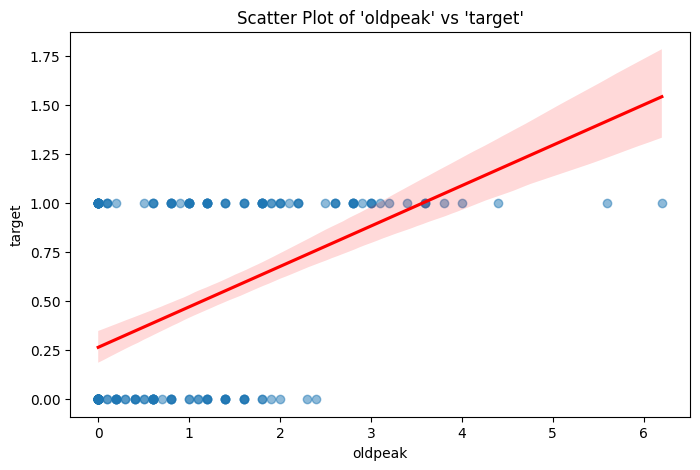

In [693]:
### Execute the analysis on the train data for each fold. 
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


fold = 1
for train_index, val_index in kf.split(train_data):
    print(f"Fold {fold}:")
    
    # Split the data into training and validation sets for this fold
    train_fold = train_data.iloc[train_index]
    val_fold = train_data.iloc[val_index]
    
    # Display the sizes of the splits
    print(f"  Training set size: {len(train_fold)}")
    print(f"  Validation set size: {len(val_fold)}")
    
    # Analyze categorical variables
    for column in categorical_columns:
        print(f"Analyzing categorical variable: {column}")
        association_categorical(train_fold, column)
    
    # Analyze continuous variables
    for column in continuous_columns:
        print(f"Analyzing continuous variable: {column}")
        association_continuous(train_fold, column)
    
    # Increment fold counter
    fold += 1

# Correlations with target 

Sex: Contrary to what is expected we have a higher proportion of females with heart disease. May be some sample bias. 
CP: In general, 1 has a higher proportion, zero is lower than 1 but higher than 2 and 3. One hot encoding may be valuable for this variable. 
FBS: I dont see a significant difference in the target between the values of the indicator function. This supports the analysis of the paper cited above that this relationship may be non-linear and the cutoff of 120 may not capture the differences. I see limited value in adding this variable to the model. As feedback to the data owner, it could be more useful if possible to have the actual value rather than the encoded indicator. 
RESTECG: Lower incidence of heart disease for zero rahter than 2. Relationship is positive as expected. This is likely an important predictor 
EXANG: This is a strong predictor, the direction of the relationship is intuitive. 
SLOPE: Another strong predictor, may be worhwile to break into a dummy variable with value of 0 for 2 (flat) and 1 o.w. Flat is correlated with lower incidence 
CA: This is a strong predictor. Based on the relation with the target, it does seem that the value of 4 is an incorrect encoding of zero. I would venture to recode 4 as zero and break the variable into a dummy if the model complexity is high introducing 3 dummys for this enconding of CA for a logistic regression for example. The relationship is not intuitive, but maybe its self selection and only patients at risk take this study.  
TAHL: this relationship varies a lot by fold, there is an error in the encoding and it is not clear how to interpret it. 

AGE: Positively related to the target.  
TRESTBPS, CHOL, OLDPEAK: Positively related.  
THALACH: Strong predictor with possibly not intuitive relationship. Some of this could be clarified by reviewing the correlation across candidate predictors between themselves or by running a multivariate model such as logistic regression. 

# Relationship between candidate predictive variables

In [694]:
### I want now to analyze the relationships between the predictive variables between themselves. This can help 
# us identify multicollinearity issues or other relationships that might be important for the model or to understand
# the relationships between the target and the predictive variables.  

### First I have some functions to analyze the associations. for continous variables I will use pair plots. Same will be done for continous and discrete variables 
 

def plot_pairplot(data, continuous_columns, discrete_col=None):
    """
    Plots a pairplot for continuous variables, optionally grouped by a discrete variable.

    Parameters:
    - data: DataFrame containing the data.
    - continuous_columns: List of continuous variable names.
    - discrete_col: Name of the discrete variable to use as the hue (optional).
    """
    if discrete_col:
        # Pairplot with hue for grouping by the discrete variable
        sns.pairplot(data, vars=continuous_columns, hue=discrete_col, palette="Set2", diag_kind="kde", corner=True)
        plt.suptitle(f"Pairplot of Continuous Variables Grouped by {discrete_col}", y=1.02)
    else:
        # Pairplot without hue (continuous vs continuous only)
        sns.pairplot(data, vars=continuous_columns, diag_kind="kde", corner=True)
        plt.suptitle("Pairplot of Continuous Variables", y=1.02)
    plt.show()


### For discrete variables I will use contingency tables.

def contingency_table(data, col1, col2):
    """
    Displays a contingency table for two categorical variables.

    Parameters:
    - data: DataFrame containing the data.
    - col1: First categorical variable.
    - col2: Second categorical variable.
    """
    contingency_table = pd.crosstab(data[col1], data[col2])
    print(f"Contingency Table for {col1} and {col2}:\n")
    print(contingency_table)
    print("\n")






  Training set size: 194
  Validation set size: 48
Pairplot for Continuous Variables:


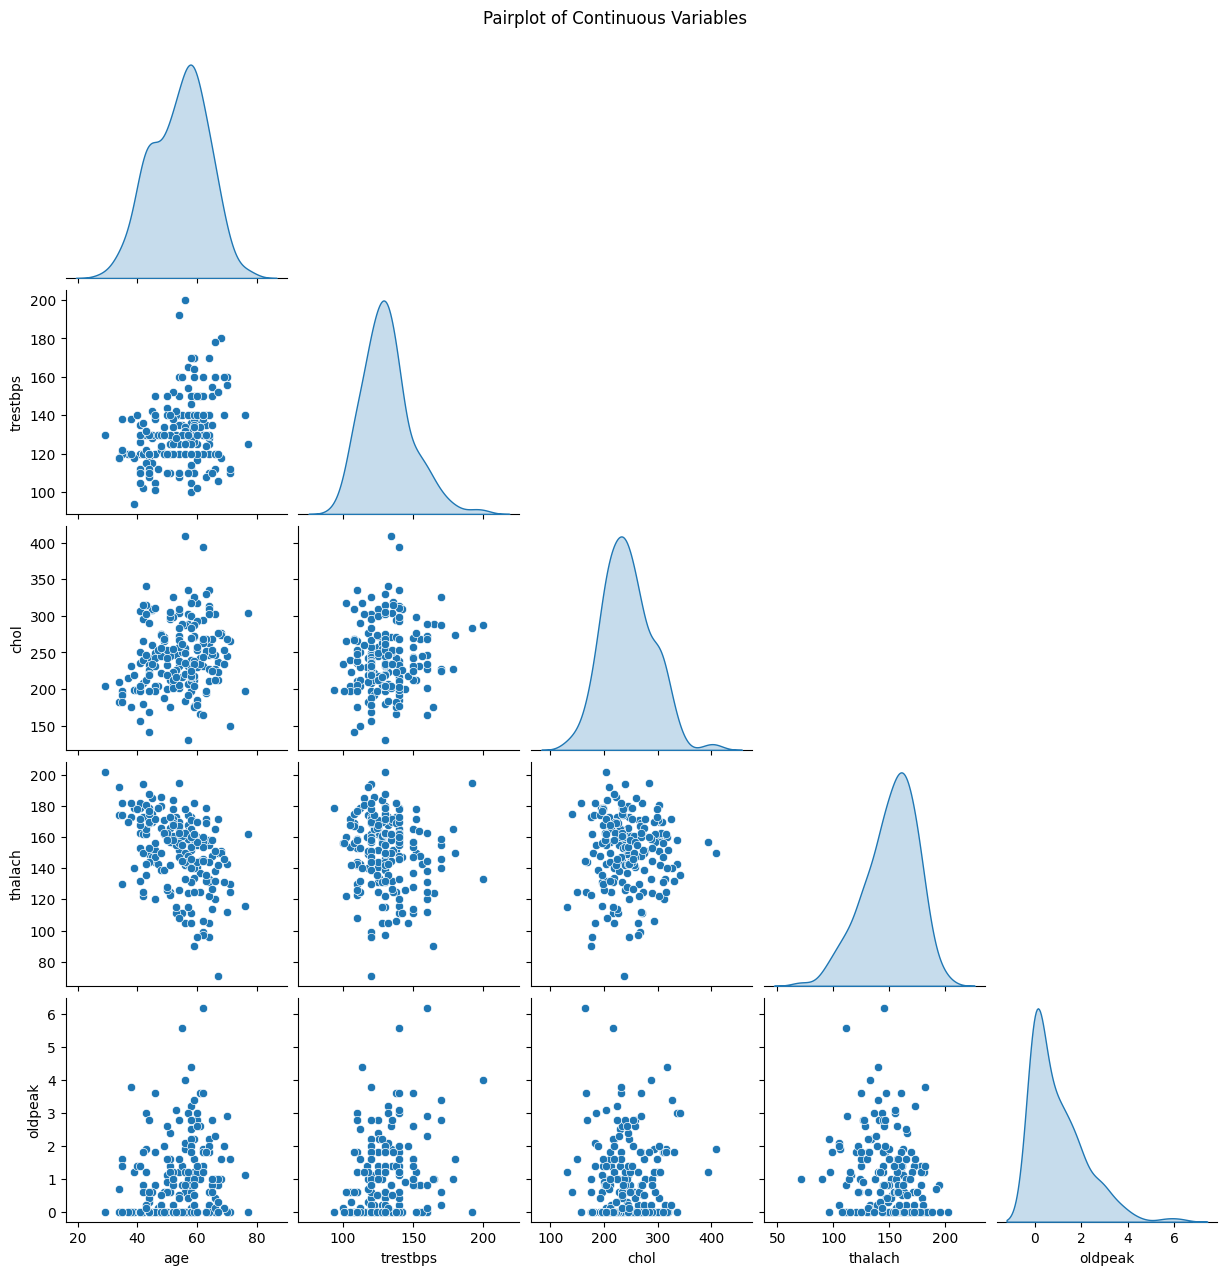

Pairplot for Continuous Variables Grouped by sex:


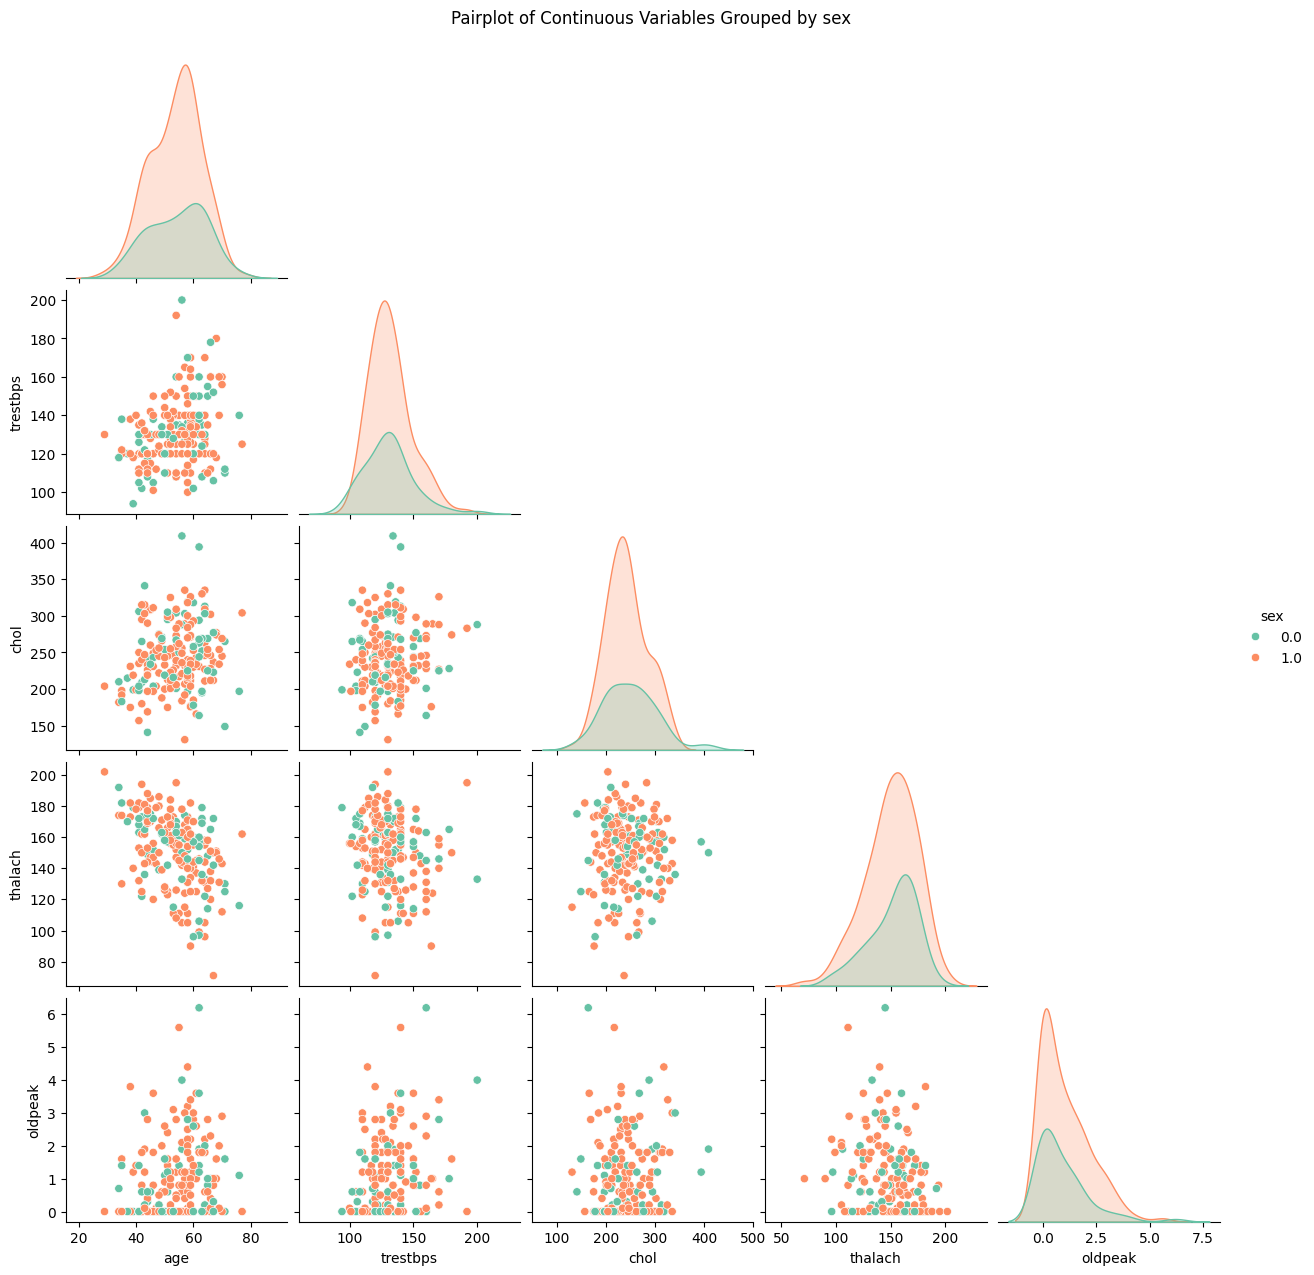

Pairplot for Continuous Variables Grouped by cp:


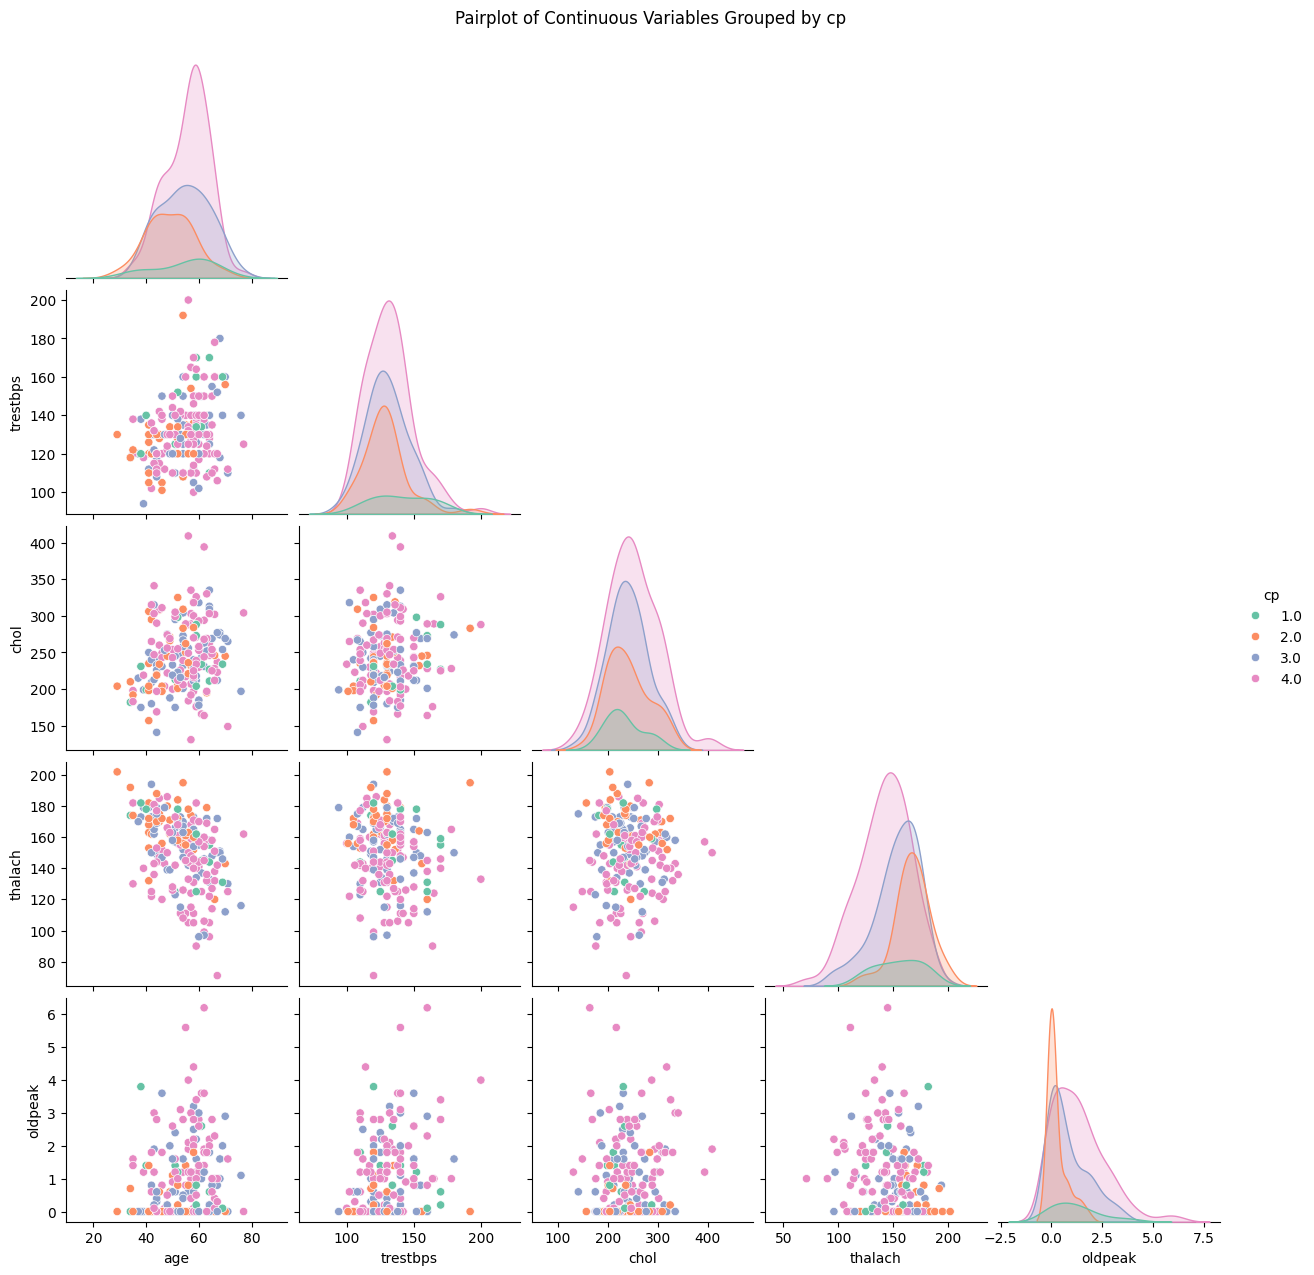

Pairplot for Continuous Variables Grouped by fbs:


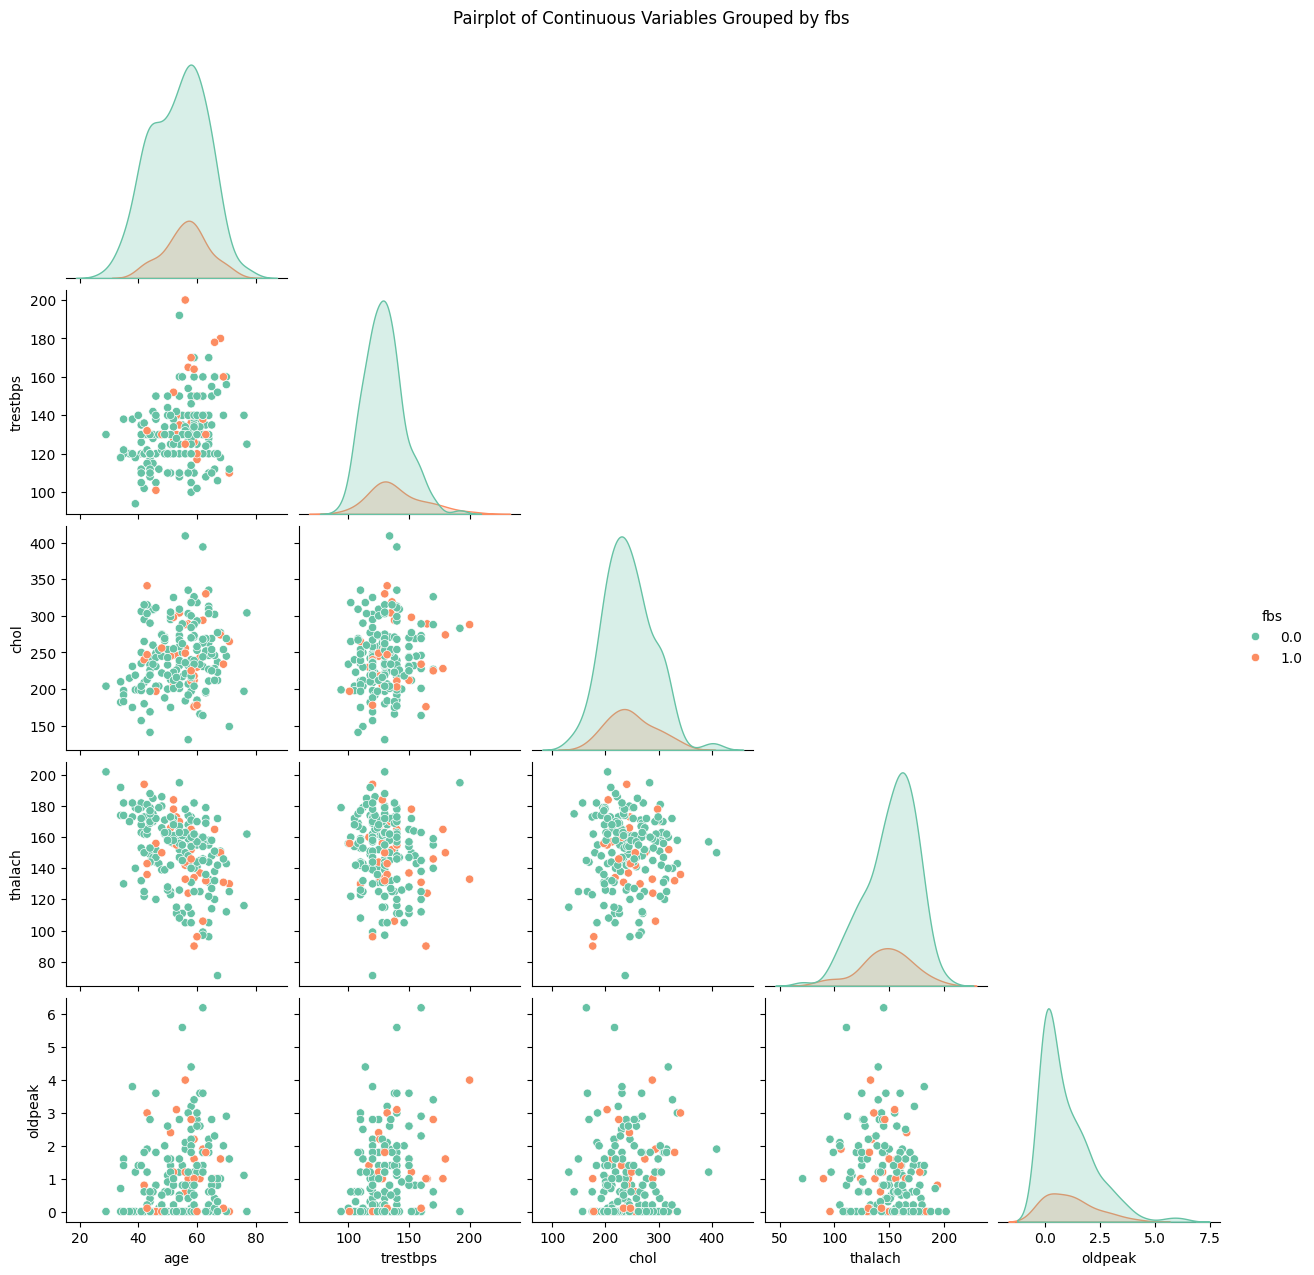

Pairplot for Continuous Variables Grouped by restecg:


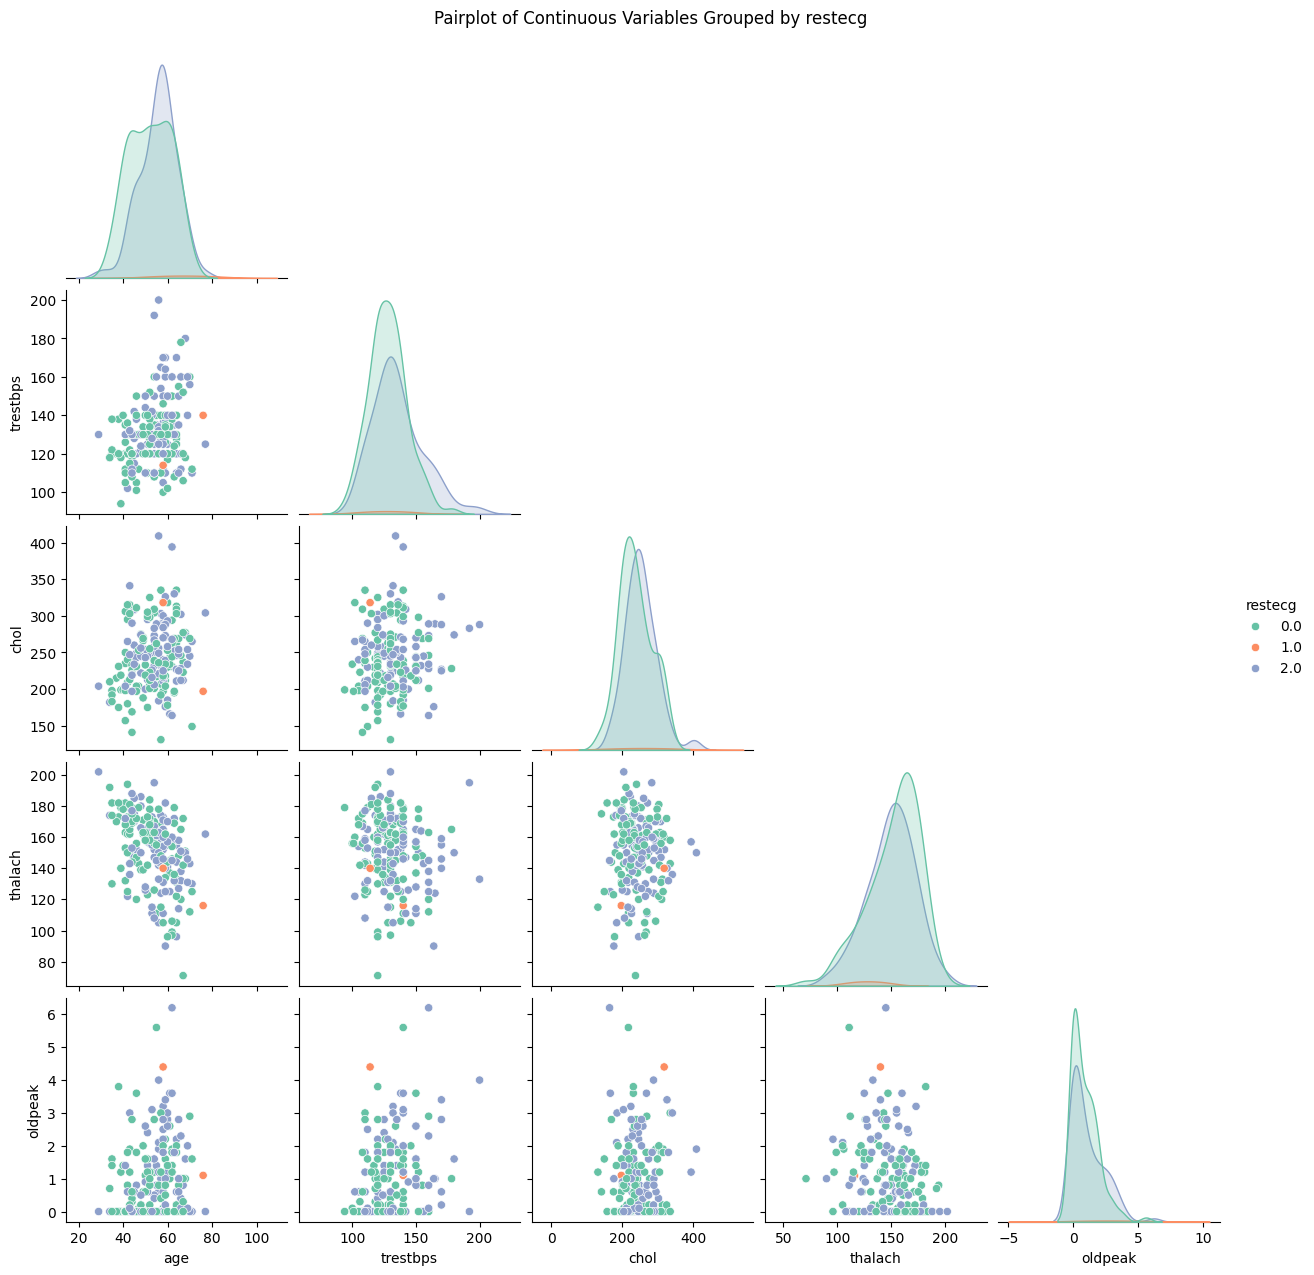

Pairplot for Continuous Variables Grouped by exang:


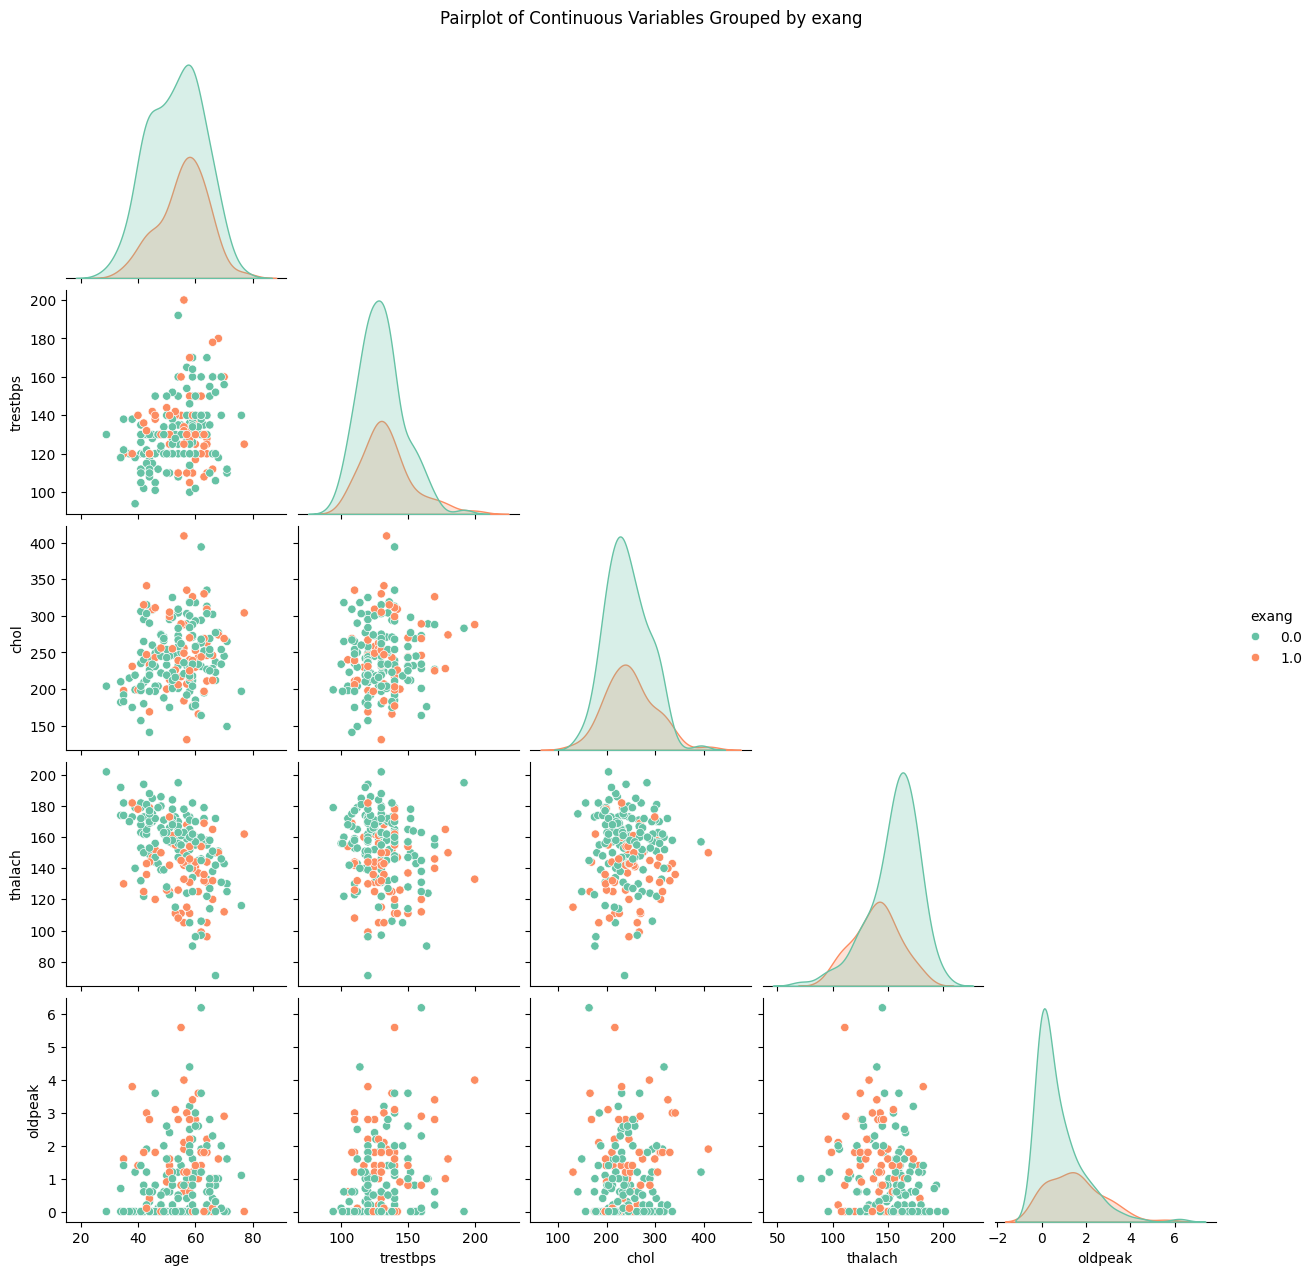

Pairplot for Continuous Variables Grouped by slope:


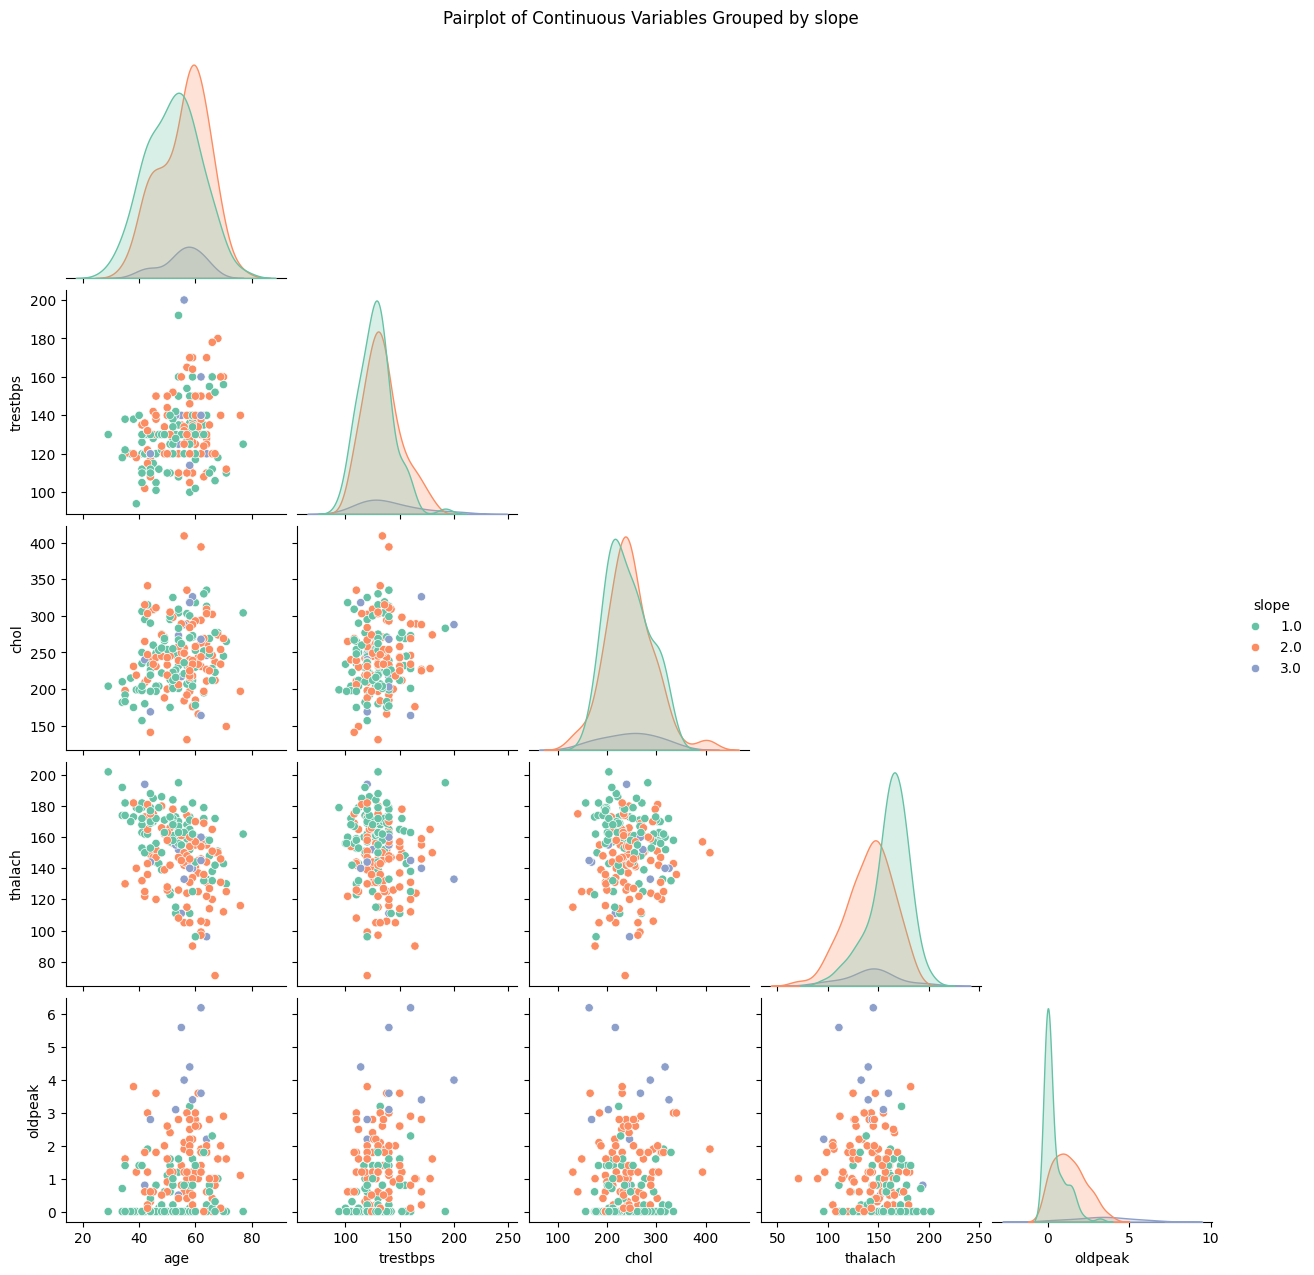

Pairplot for Continuous Variables Grouped by ca:


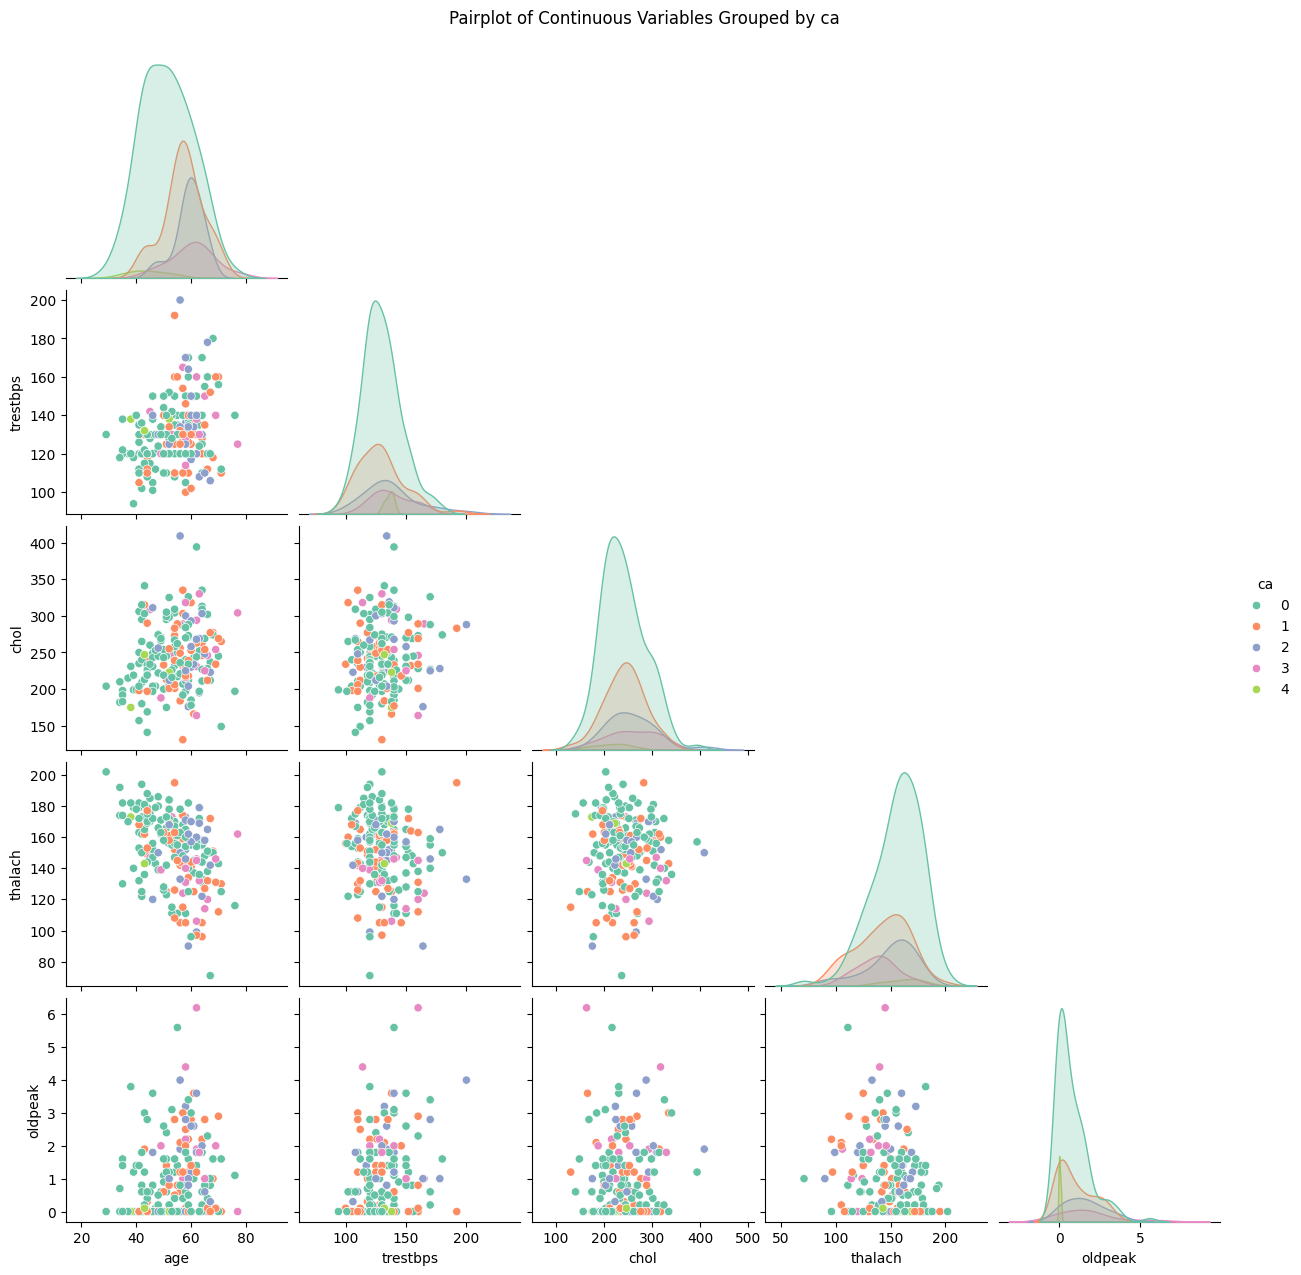

Pairplot for Continuous Variables Grouped by thal:


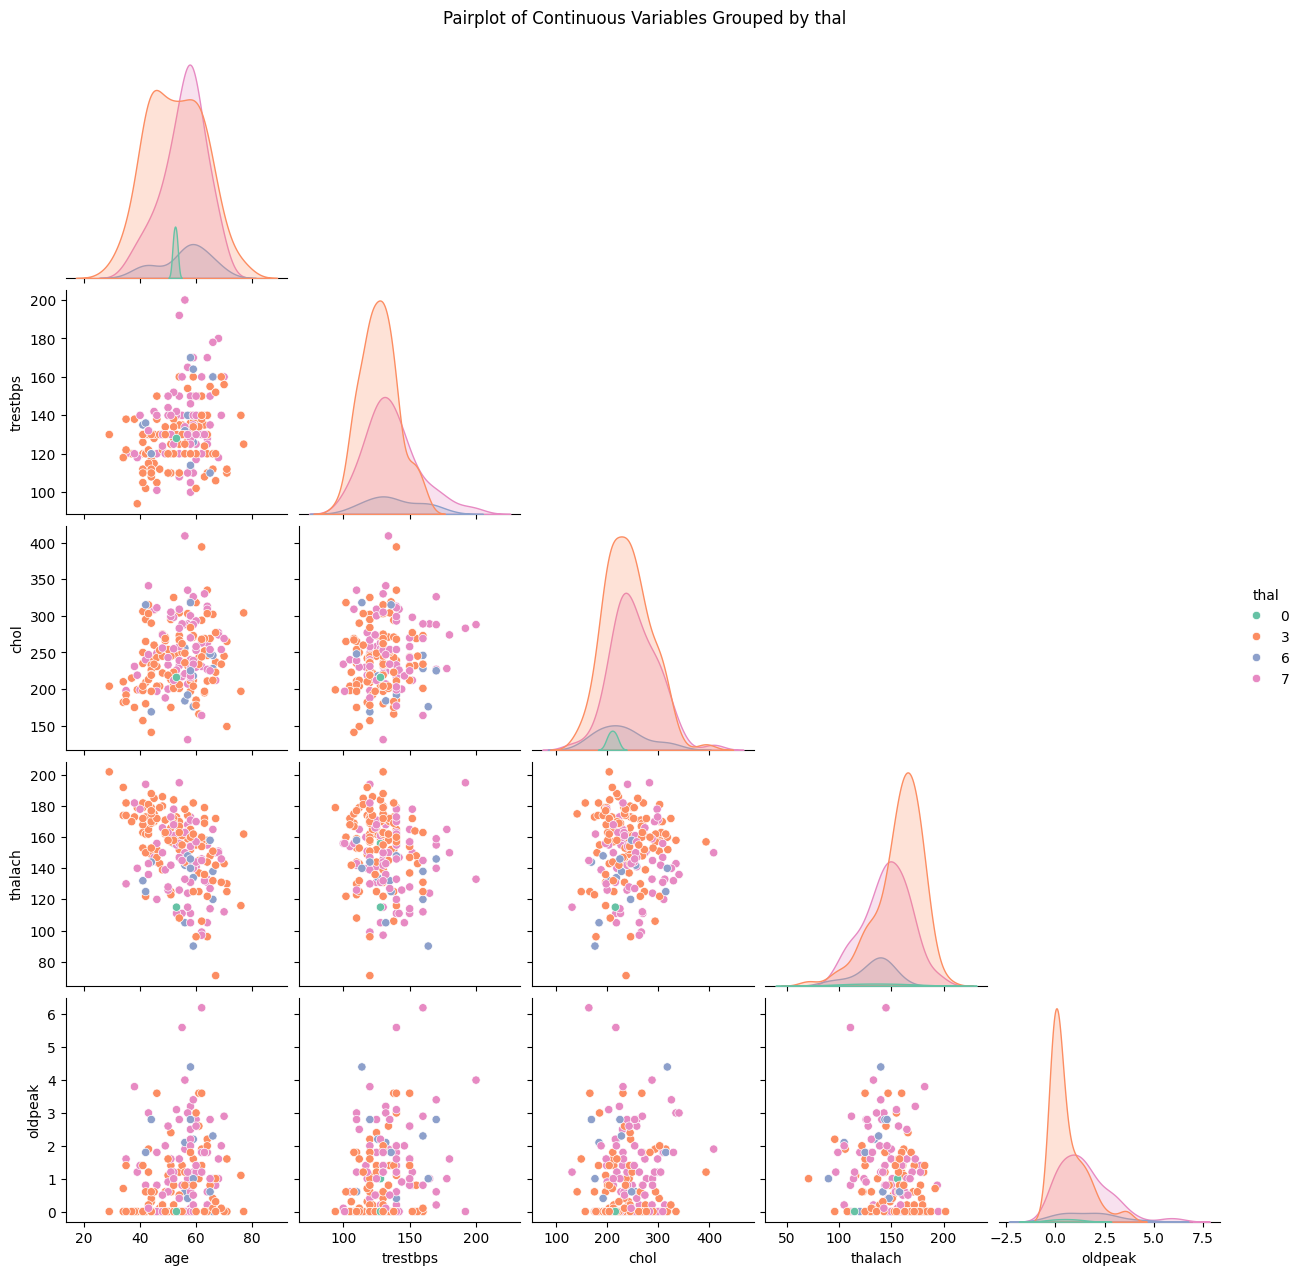

In [695]:
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
continuous_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


fold = 1
# Split the data into training and validation sets for this fold
train_fold = train_data.iloc[train_index]
val_fold = train_data.iloc[val_index]
    
    # Display the sizes of the splits
print(f"  Training set size: {len(train_fold)}")
print(f"  Validation set size: {len(val_fold)}")
    
    # Pairplot for continuous variables
print("Pairplot for Continuous Variables:")
plot_pairplot(train_fold, continuous_columns)
    
    # Pairplot for continuous variables grouped by discrete variables
for discrete_col in categorical_columns:
    print(f"Pairplot for Continuous Variables Grouped by {discrete_col}:")
    plot_pairplot(train_fold, continuous_columns, discrete_col=discrete_col)
    
    

In [696]:
print("Contingency Tables for Categorical Variables:")
for i, col1 in enumerate(categorical_columns):
    for col2 in categorical_columns[i+1:]:
        contingency_table(train_fold, col1, col2)

Contingency Tables for Categorical Variables:
Contingency Table for sex and cp:

cp   1.0  2.0  3.0  4.0
sex                    
0.0    0   12   22   25
1.0   12   24   35   64


Contingency Table for sex and fbs:

fbs  0.0  1.0
sex          
0.0   50    9
1.0  113   22


Contingency Table for sex and restecg:

restecg  0.0  1.0  2.0
sex                   
0.0       35    1   23
1.0       68    1   66


Contingency Table for sex and exang:

exang  0.0  1.0
sex            
0.0     49   10
1.0     86   49


Contingency Table for sex and slope:

slope  1.0  2.0  3.0
sex                 
0.0     28   28    3
1.0     66   61    8


Contingency Table for sex and ca:

ca    0   1   2   3  4
sex                   
0.0  36   9  11   3  0
1.0  75  34  12  11  3


Contingency Table for sex and thal:

thal  0   3   6   7
sex                
0.0   1  47   1  10
1.0   1  59  12  63


Contingency Table for cp and fbs:

fbs  0.0  1.0
cp           
1.0   10    2
2.0   33    3
3.0   45   12
4.0   75   1

In [697]:
from scipy.stats import f_oneway

def run_anova(data, categorical_columns, continuous_columns, target_col="target"):
    """
    Runs ANOVA tests for all combinations of categorical and continuous variables.

    Parameters:
    - data: DataFrame containing the data.
    - categorical_columns: List of categorical variable names.
    - continuous_columns: List of continuous variable names.
    - target_col: Name of the target variable (optional, default is 'target').

    Returns:
    - A DataFrame summarizing the ANOVA results.
    """
    results = []

    for cat_col in categorical_columns:
        for cont_col in continuous_columns:
            # Group the continuous variable by the categories of the categorical variable
            groups = [group[cont_col].values for name, group in data.groupby(cat_col)]
            
            # Perform ANOVA
            f_stat, p_value = f_oneway(*groups)
            
            # Append the results
            results.append({
                "Categorical Variable": cat_col,
                "Continuous Variable": cont_col,
                "F-Statistic": f_stat,
                "p-Value": p_value
            })

    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    return results_df

anova_results = run_anova(train_fold, categorical_columns, continuous_columns)

# Display the results
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
   Categorical Variable Continuous Variable  F-Statistic       p-Value
0                   sex                 age     0.166007  6.841395e-01
1                   sex            trestbps     0.164428  6.855635e-01
2                   sex                chol     1.025534  3.124845e-01
3                   sex             thalach     0.161666  6.880746e-01
4                   sex             oldpeak     0.741737  3.901794e-01
5                    cp                 age     4.645533  3.698224e-03
6                    cp            trestbps     1.624440  1.851101e-01
7                    cp                chol     0.879104  4.529416e-01
8                    cp             thalach    12.684355  1.359152e-07
9                    cp             oldpeak     8.970258  1.380090e-05
10                  fbs                 age     2.267405  1.337644e-01
11                  fbs            trestbps     9.504349  2.351658e-03
12                  fbs                chol     0.352344  5.53

In [698]:
from scipy.stats import chi2_contingency

def run_chi_square(data, categorical_columns):
    """
    Runs Chi-Square tests for all pairs of categorical variables.

    Parameters:
    - data: DataFrame containing the data.
    - categorical_columns: List of categorical variable names.

    Returns:
    - A DataFrame summarizing the Chi-Square test results.
    """
    results = []

    for i, col1 in enumerate(categorical_columns):
        for col2 in categorical_columns[i+1:]:
            # Create a contingency table
            contingency_table = pd.crosstab(data[col1], data[col2])
            
            # Perform the Chi-Square test
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            
            # Append the results
            results.append({
                "Variable 1": col1,
                "Variable 2": col2,
                "Chi2 Statistic": chi2,
                "p-Value": p,
                "Degrees of Freedom": dof
            })

    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    return results_df

In [699]:
# Run Chi-Square tests for all pairs of categorical variables
chi_square_results = run_chi_square(train_fold, categorical_columns)

# Display the results
print("Chi-Square Test Results:")
print(chi_square_results)

Chi-Square Test Results:
   Variable 1 Variable 2  Chi2 Statistic       p-Value  Degrees of Freedom
0         sex         cp        7.420416  5.963896e-02                   3
1         sex        fbs        0.000000  1.000000e+00                   1
2         sex    restecg        1.860419  3.944710e-01                   2
3         sex      exang        6.376239  1.156583e-02                   1
4         sex      slope        0.114808  9.442124e-01                   2
5         sex         ca        7.181432  1.266054e-01                   4
6         sex       thal       22.884530  4.268395e-05                   3
7          cp        fbs        2.668619  4.455866e-01                   3
8          cp    restecg        8.842391  1.826379e-01                   6
9          cp      exang       42.988137  2.475316e-09                   3
10         cp      slope       24.232370  4.732711e-04                   6
11         cp         ca       24.430200  1.776614e-02                  12


Some comments on relationship between variables: 

Age is negatively correlated with talach and positively with chol and tresbps. This can help explain the unintuitive correlations that we saw earlier. Oldpeak seems to be exogenous from the other variables, so it is a strong candidate to be included even in simple models. CP and EXANG seem to be highly related as SEX and THAL. Also CP and CA. 

# Feature selection and transformation

I will select a few candidate features and recode some of the variables to make them interpretable in logistic regression, which will be the first candidate model. 

I believe regarding the continuous features that age should enter even the simplest model. So should oldpeak as this variable was somewhat exogenous to the others. An interaction between age and sex could be included. 

For the categorical variables I would include sex, a dummy for CP 0 or other values, and a dummy for rest ECG 0 or other value and an interaction between them. EXANG seems important as well. FBS and Thal may not be helpful based on the above analysis. 

In [700]:
# Baseline model 
## This is a very simple model I dont want to start with a complex model, specially given the number of datapoints in the set. Only six features plus the constant term. 

# Define predictors
predictors = ['age', 'sex', 'oldpeak', 'chest_pain', 'resting_ecg', 'exang']

# Initialize lists to store metrics for each fold
accuracy_list = []
auc_list = []
precision_list = []
recall_list = []
f1_list = []

# Perform 5-fold cross-validation
fold = 1
for train_index, val_index in kf.split(train_data):
    print(f"Fold {fold}:")
    
    # Split the data into training and validation sets for this fold
    train_fold = train_data.iloc[train_index]
    val_fold = train_data.iloc[val_index]
    
    # Display the sizes of the splits
    print(f"  Training set size: {len(train_fold)}")
    print(f"  Validation set size: {len(val_fold)}")
    
    # Define predictors and target for the training set
    X_train = train_fold[predictors]
    y_train = train_fold['target']
    
    # Add a constant for the intercept
    X_train = sm.add_constant(X_train)
    
    # Fit the logistic regression model
    logit_model = sm.Logit(y_train, X_train)
    result = logit_model.fit(disp=False)  # Suppress detailed output for each fold
    
    # Prepare the validation set
    X_val = val_fold[predictors]
    y_val = val_fold['target']
    
    # Add a constant for the intercept in the validation set
    X_val = sm.add_constant(X_val)
    
    # Predict probabilities and classes on the validation set
    y_pred_prob = result.predict(X_val)
    y_pred_class = (y_pred_prob >= 0.5).astype(int)
    
    # Evaluate the model
    accuracy = accuracy_score(y_val, y_pred_class)
    auc = roc_auc_score(y_val, y_pred_prob)
    precision = precision_score(y_val, y_pred_class)
    recall = recall_score(y_val, y_pred_class)
    f1 = f1_score(y_val, y_pred_class)
    
    # Append metrics to lists
    accuracy_list.append(accuracy)
    auc_list.append(auc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    
    # Print metrics for the current fold
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  AUC: {auc:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    
    # Increment fold counter
    fold += 1

# Calculate and print average metrics across all folds
print("\nAverage Metrics Across All Folds:")
print(f"  Average Accuracy: {np.mean(accuracy_list):.2f}")
print(f"  Average AUC: {np.mean(auc_list):.2f}")
print(f"  Average Precision: {np.mean(precision_list):.2f}")
print(f"  Average Recall: {np.mean(recall_list):.2f}")
print(f"  Average F1-Score: {np.mean(f1_list):.2f}")

Fold 1:
  Training set size: 193
  Validation set size: 49
  Accuracy: 0.80
  AUC: 0.91
  Precision: 0.80
  Recall: 0.80
  F1-Score: 0.80
Fold 2:
  Training set size: 193
  Validation set size: 49
  Accuracy: 0.76
  AUC: 0.84
  Precision: 0.71
  Recall: 0.83
  F1-Score: 0.77
Fold 3:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.83
  AUC: 0.90
  Precision: 0.85
  Recall: 0.77
  F1-Score: 0.81
Fold 4:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.81
  AUC: 0.86
  Precision: 0.79
  Recall: 0.75
  F1-Score: 0.77
Fold 5:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.83
  AUC: 0.90
  Precision: 0.84
  Recall: 0.84
  F1-Score: 0.84

Average Metrics Across All Folds:
  Average Accuracy: 0.81
  Average AUC: 0.88
  Average Precision: 0.80
  Average Recall: 0.80
  Average F1-Score: 0.80


The average results indicate an accuracy of 81% and AUC of .88. Precision and recall are quite balanced. The predictors seem relevant for the task at hand and the model performance is acceptable considering is quite a simple model. I will try adding more variables.

In [701]:
### Here I tried several specifications but the best in terms of the metrics is presented below. 

predictors = ['sex','exang', 'ca_dummy', 'oldpeak', 'slope_not_flat', 'cp_2.0', 'cp_3.0', 'cp_4.0']

# Initialize lists to store metrics for each fold
accuracy_list = []
auc_list = []
precision_list = []
recall_list = []
f1_list = []

# Perform 5-fold cross-validation
fold = 1
for train_index, val_index in kf.split(train_data):
    print(f"Fold {fold}:")
    
    # Split the data into training and validation sets for this fold
    train_fold = train_data.iloc[train_index]
    val_fold = train_data.iloc[val_index]
    
    # Display the sizes of the splits
    print(f"  Training set size: {len(train_fold)}")
    print(f"  Validation set size: {len(val_fold)}")
    
    # Define predictors and target for the training set
    X_train = train_fold[predictors]
    y_train = train_fold['target']
    
    # Add a constant for the intercept
    X_train = sm.add_constant(X_train)
    
    # Fit the logistic regression model
    logit_model = sm.Logit(y_train, X_train)
    result = logit_model.fit(disp=False)  # Suppress detailed output for each fold
    
    # Prepare the validation set
    X_val = val_fold[predictors]
    y_val = val_fold['target']
    
    # Add a constant for the intercept in the validation set
    X_val = sm.add_constant(X_val)
    
    # Predict probabilities and classes on the validation set
    y_pred_prob = result.predict(X_val)
    y_pred_class = (y_pred_prob >= 0.5).astype(int)
    
    # Evaluate the model
    accuracy = accuracy_score(y_val, y_pred_class)
    auc = roc_auc_score(y_val, y_pred_prob)
    precision = precision_score(y_val, y_pred_class)
    recall = recall_score(y_val, y_pred_class)
    f1 = f1_score(y_val, y_pred_class)
    
    # Append metrics to lists
    accuracy_list.append(accuracy)
    auc_list.append(auc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    
    # Print metrics for the current fold
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  AUC: {auc:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    
    # Increment fold counter
    fold += 1

# Calculate and print average metrics across all folds
print("\nAverage Metrics Across All Folds:")
print(f"  Average Accuracy: {np.mean(accuracy_list):.2f}")
print(f"  Average AUC: {np.mean(auc_list):.2f}")
print(f"  Average Precision: {np.mean(precision_list):.2f}")
print(f"  Average Recall: {np.mean(recall_list):.2f}")
print(f"  Average F1-Score: {np.mean(f1_list):.2f}")


Fold 1:
  Training set size: 193
  Validation set size: 49
  Accuracy: 0.92
  AUC: 0.93
  Precision: 0.96
  Recall: 0.88
  F1-Score: 0.92
Fold 2:
  Training set size: 193
  Validation set size: 49
  Accuracy: 0.84
  AUC: 0.91
  Precision: 0.81
  Recall: 0.88
  F1-Score: 0.84
Fold 3:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.88
  AUC: 0.92
  Precision: 0.83
  Recall: 0.91
  F1-Score: 0.87
Fold 4:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.75
  AUC: 0.89
  Precision: 0.68
  Recall: 0.75
  F1-Score: 0.71
Fold 5:
  Training set size: 194
  Validation set size: 48
  Accuracy: 0.88
  AUC: 0.93
  Precision: 0.91
  Recall: 0.84
  F1-Score: 0.88

Average Metrics Across All Folds:
  Average Accuracy: 0.85
  Average AUC: 0.92
  Average Precision: 0.84
  Average Recall: 0.85
  Average F1-Score: 0.84


After several specifications, the candidate model with the features 'sex', 'exang', 'ca_dummy', 'oldpeak', 'slope_not_flat' (an indicator of whether slope is different from 2) and dummy variables for the values of chest pain was selected as it achieved slightly higher accuracy, AUC, and importantly a .05 increase in recall as compared with the baseline model. 

A potentially good model for this case is a Random Forest classifier. Random Forests are advantageous because they do not require feature transformations, simplifying the preprocessing pipeline. Additionally, they can automatically capture interactions and nonlinear relationships in the data, which may not be fully captured by a logistic regression model. Evaluating a Random Forest model can also help determine whether the performance of the logistic regression model is close to what can be achieved by a more complex ensemble model. 

Fold 1:
  Accuracy: 0.92
  AUC: 0.96
  Precision: 0.96
  Recall: 0.88
  F1-Score: 0.92
Fold 2:
  Accuracy: 0.80
  AUC: 0.91
  Precision: 0.82
  Recall: 0.75
  F1-Score: 0.78
Fold 3:
  Accuracy: 0.85
  AUC: 0.91
  Precision: 0.86
  Recall: 0.82
  F1-Score: 0.84
Fold 4:
  Accuracy: 0.81
  AUC: 0.87
  Precision: 0.79
  Recall: 0.75
  F1-Score: 0.77
Fold 5:
  Accuracy: 0.83
  AUC: 0.92
  Precision: 0.87
  Recall: 0.80
  F1-Score: 0.83

Average Metrics Across All Folds:
  Average Accuracy: 0.84
  Average AUC: 0.91
  Average Precision: 0.86
  Average Recall: 0.80
  Average F1-Score: 0.83

Feature Importance (Average Across Folds):
          Average_Importance
oldpeak             0.137936
thal                0.124529
ca                  0.122923
cp                  0.112463
thalach             0.102373
age                 0.095656
trestbps            0.070165
chol                0.069712
exang               0.068532
slope               0.037676
sex                 0.025773
restecg            

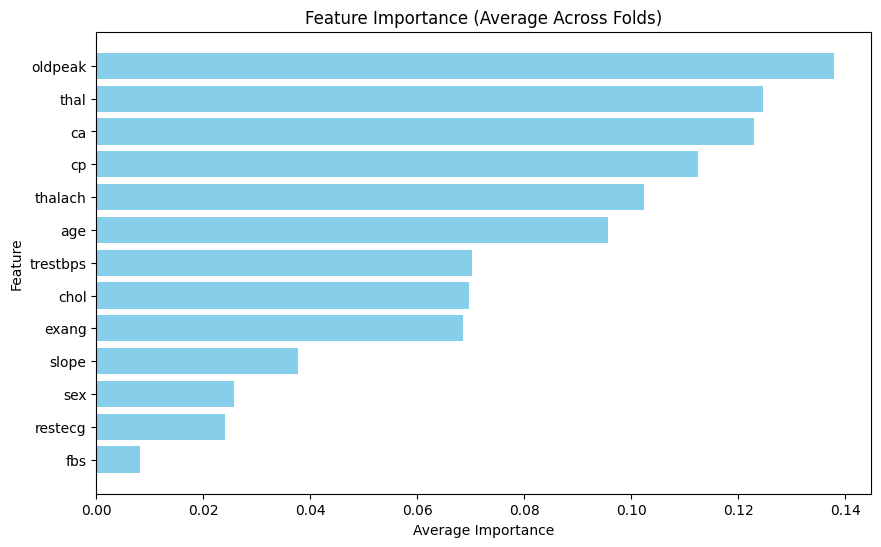

In [702]:
# Define predictors and target

predictors = categorical_columns + continuous_columns
X = train_data[predictors]
y = train_data['target']

# Perform 5-fold cross-validation
fold = 1
accuracy_list = []
auc_list = []
precision_list = []
recall_list = []
f1_list = []

# Initialize a DataFrame to store feature importance for each fold
feature_importance_df = pd.DataFrame(0, index=predictors, columns=[f"Fold_{i+1}" for i in range(5)])

for train_index, val_index in kf.split(X, y):
    print(f"Fold {fold}:")
    
    # Split the data into training and validation sets
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train the Random Forest model
    # I selected the hyperparameters based on a few executions of the model and moving slighlty from the standard values. 
    # the results of grid search show these values are close to the best ones within the range I tried. This analysis is conducted in the next cell.
    rf_model = RandomForestClassifier(n_estimators=50, random_state=1001, max_features=4, max_depth=10)
    rf_model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred_class = rf_model.predict(X_val)
    y_pred_prob = rf_model.predict_proba(X_val)[:, 1]
    
    # Evaluate the model
    accuracy = accuracy_score(y_val, y_pred_class)
    auc = roc_auc_score(y_val, y_pred_prob)
    precision = precision_score(y_val, y_pred_class)
    recall = recall_score(y_val, y_pred_class)
    f1 = f1_score(y_val, y_pred_class)
    
    # Append metrics to lists
    accuracy_list.append(accuracy)
    auc_list.append(auc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    
    # Store feature importance for this fold
    feature_importance_df[f"Fold_{fold}"] = rf_model.feature_importances_
    
    # Print metrics for the current fold
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  AUC: {auc:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1-Score: {f1:.2f}")
    
    fold += 1

# Calculate and print average metrics across all folds
print("\nAverage Metrics Across All Folds:")
print(f"  Average Accuracy: {np.mean(accuracy_list):.2f}")
print(f"  Average AUC: {np.mean(auc_list):.2f}")
print(f"  Average Precision: {np.mean(precision_list):.2f}")
print(f"  Average Recall: {np.mean(recall_list):.2f}")
print(f"  Average F1-Score: {np.mean(f1_list):.2f}")

# Calculate average feature importance across all folds
feature_importance_df['Average_Importance'] = feature_importance_df.mean(axis=1)
feature_importance_df = feature_importance_df.sort_values(by='Average_Importance', ascending=False)

# Print feature importance
print("\nFeature Importance (Average Across Folds):")
print(feature_importance_df[['Average_Importance']])

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df.index, feature_importance_df['Average_Importance'], color='skyblue')
plt.xlabel('Average Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Average Across Folds)')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.show()

Finally, I will do some hyperparameter tuning for the random forest model. I created a grid with candidate values for 3 important hyperparameters: n_estimators, max_features and max_depth. I tried 5 values for n_estimators, 4 for n_parameters and 5 for max_depth. Then, I iterated over the grid and selected the combination which achieved the highest accuracy. 

In [703]:
# Define predictors and target
predictors = categorical_columns + continuous_columns
X = train_data[predictors]
y = train_data['target']

# Define hyperparameter grid
n_estimators = [30, 50, 80, 100, 150]
max_features = [3, 4, 5, 7]
max_depth = [5, 10, 15, 20, None]
param_grid = list(product(n_estimators, max_features, max_depth))  # All combinations

# Initialize variables to track the best hyperparameters and performance
best_params = None
best_accuracy = 0
results = []

# Perform hyperparameter search
for n_est, max_feat, max_d in param_grid:
    print(f"Testing parameters: n_estimators={n_est}, max_features={max_feat}, max_depth={max_d}")
    
    # Initialize lists to store metrics for each fold
    accuracy_list = []
    auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    
    # Initialize a DataFrame to store feature importance for each fold
    feature_importance_df = pd.DataFrame(0, index=predictors, columns=[f"Fold_{i+1}" for i in range(5)])
    
    fold = 1
    for train_index, val_index in kf.split(X, y):
        print(f"  Fold {fold}:")
        
        # Split the data into training and validation sets
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # Train the Random Forest model with the current hyperparameters
        rf_model = RandomForestClassifier(
            n_estimators=n_est,
            max_features=max_feat,
            max_depth=max_d,
            random_state=1001
        )
        rf_model.fit(X_train, y_train)
        
        # Predict on the validation set
        y_pred_class = rf_model.predict(X_val)
        y_pred_prob = rf_model.predict_proba(X_val)[:, 1]
        
        # Evaluate the model
        accuracy = accuracy_score(y_val, y_pred_class)
        auc = roc_auc_score(y_val, y_pred_prob)
        precision = precision_score(y_val, y_pred_class)
        recall = recall_score(y_val, y_pred_class)
        f1 = f1_score(y_val, y_pred_class)
        
        # Append metrics to lists
        accuracy_list.append(accuracy)
        auc_list.append(auc)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        
        # Store feature importance for this fold
        feature_importance_df[f"Fold_{fold}"] = rf_model.feature_importances_
        
        # Print metrics for the current fold
        print(f"    Accuracy: {accuracy:.2f}")
        print(f"    AUC: {auc:.2f}")
        print(f"    Precision: {precision:.2f}")
        print(f"    Recall: {recall:.2f}")
        print(f"    F1-Score: {f1:.2f}")
        
        fold += 1
    
    # Calculate average metrics across all folds
    avg_accuracy = np.mean(accuracy_list)
    avg_auc = np.mean(auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    
    # Store results for this parameter combination
    results.append({
        'n_estimators': n_est,
        'max_features': max_feat,
        'max_depth': max_d,
        'avg_accuracy': avg_accuracy,
        'avg_auc': avg_auc,
        'avg_precision': avg_precision,
        'avg_recall': avg_recall,
        'avg_f1': avg_f1
    })
    
    # Update the best parameters if this combination is better
    if avg_accuracy > best_accuracy:
        best_accuracy = avg_accuracy
        best_params = (n_est, max_feat, max_d)

# Print the best hyperparameters and their performance
print("\nBest Hyperparameters:")
print(f"  n_estimators: {best_params[0]}")
print(f"  max_features: {best_params[1]}")
print(f"  max_depth: {best_params[2]}")
print(f"  Best Accuracy: {best_accuracy:.2f}")

# Convert results to a DataFrame for analysis
results_df = pd.DataFrame(results)

# Display the top 5 parameter combinations
print("\nTop 5 Parameter Combinations:")
print(results_df.sort_values(by='avg_accuracy', ascending=False).head())


Testing parameters: n_estimators=30, max_features=3, max_depth=5
  Fold 1:
    Accuracy: 0.90
    AUC: 0.94
    Precision: 0.95
    Recall: 0.84
    F1-Score: 0.89
  Fold 2:
    Accuracy: 0.82
    AUC: 0.88
    Precision: 0.83
    Recall: 0.79
    F1-Score: 0.81
  Fold 3:
    Accuracy: 0.81
    AUC: 0.91
    Precision: 0.84
    Recall: 0.73
    F1-Score: 0.78
  Fold 4:
    Accuracy: 0.81
    AUC: 0.88
    Precision: 0.82
    Recall: 0.70
    F1-Score: 0.76
  Fold 5:
    Accuracy: 0.81
    AUC: 0.91
    Precision: 0.83
    Recall: 0.80
    F1-Score: 0.82
Testing parameters: n_estimators=30, max_features=3, max_depth=10
  Fold 1:
    Accuracy: 0.86
    AUC: 0.94
    Precision: 0.88
    Recall: 0.84
    F1-Score: 0.86
  Fold 2:
    Accuracy: 0.82
    AUC: 0.91
    Precision: 0.89
    Recall: 0.71
    F1-Score: 0.79
  Fold 3:
    Accuracy: 0.83
    AUC: 0.90
    Precision: 0.85
    Recall: 0.77
    F1-Score: 0.81
  Fold 4:
    Accuracy: 0.79
    AUC: 0.87
    Precision: 0.75
    Recall: 0.

# Final model selection. 

In terms of performance, logistic regression achieved average accuracy of .85 vs random forest with .84. The logistic regression has a .01 higher AUC and .05 higher recall, but lower precision by .01. 

The logistic regression has some other tangible advantages over the random forest: 

1.- We can directly interpret the coefficients and link them to changes in log odds, which makes the model more explainable. This could be helpful if the model outputs need to be explained to patients or regulators.  
2.- It uses a subset of features and even simplifies those features. This is easier to interpret, may result in a less costly data collection process (e.g. since the model does not use restecg that study would not need to be performed and the results recorded going forward for model purposes if that data is not already being collected for other reasons), and it is less prone to be affected by errors in data storage or acquisition (as an example, the value of 4 observed in the flourosopy would not affect the model if we put it in production as the final model only uses a dummy for presence or abscence of mayor vessels in the study.) 

For the above reasons I will keep the logistic regression model as the final proposal. 

In [704]:
## Final model 

predictors = ['sex','exang', 'ca_dummy', 'oldpeak', 'slope_not_flat', 'cp_2.0', 'cp_3.0', 'cp_4.0']


# Define predictors and target for the test data
X_test = test_data[predictors]
y_test = test_data['target']

# Add a constant for the intercept
X_test = sm.add_constant(X_test)

# Train the logistic regression model on the entire training data
X_train = train_data[predictors]
y_train = train_data['target']
X_train = sm.add_constant(X_train)

logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()

# Print the model coefficients
print("\nModel Coefficients:")
print(result.summary())

# Predict probabilities and classes on the test data
y_pred_prob = result.predict(X_test)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
print("\nConfusion Matrix:")
print(conf_matrix)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)  # Sensitivity
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])  # TN / (TN + FP)
auc = roc_auc_score(y_test, y_pred_prob)

# Print metrics
print("\nMetrics on Test Data:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall (Sensitivity): {recall:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"AUC: {auc:.2f}")

# Classification Report (optional)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

Optimization terminated successfully.
         Current function value: 0.320386
         Iterations 7

Model Coefficients:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  242
Model:                          Logit   Df Residuals:                      233
Method:                           MLE   Df Model:                            8
Date:                Fri, 02 May 2025   Pseudo R-squ.:                  0.5372
Time:                        16:52:51   Log-Likelihood:                -77.533
converged:                       True   LL-Null:                       -167.53
Covariance Type:            nonrobust   LLR p-value:                 1.028e-34
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.2598      0.941     -4.528      0.000      -6.104      -2.

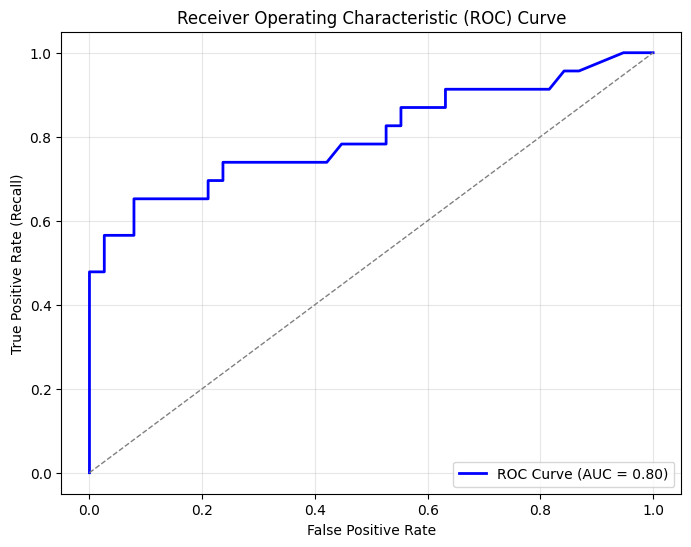

In [705]:
# Generate the predicted probabilities for the positive class
y_pred_prob = result.predict(X_test)

# Compute the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute the AUC
roc_auc_value = sklearn.metrics.auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Results 

Model performance on the test set: The accuracy of the model on the test set was of 80%. This is in-line with the results of the 5 fold cross validation which showed mean accuracy of 85%, but with some variation across folds (from 75 to 92%). The decreasee may be due to randomness and the fact the test set is not very large. Precision is of 79%, Recall 65% and Specificity is 89%. The AUC is .80. 

Interpretation:
Accuracy: 84% of observations in the test data were correctly labeled by the model. This is 51 out of 61 observations where correctly labeled. 

Precision: Indicates that 89% of the model positives are correctly labeled. In this case 32 positives assigned by the model correctly assigned (True positives) out of 36 positives assigned by the model (4 false positives). 

Recall: Indicates that 84% of the actual positives in the data where identified by the model. That is, out of 38 positives in the data, the model correctly labeled 32 with 6 being false negatives. As false negatives may be more costly in this type of medical application, some adjustment could be done to the threshold before concluding that an observation is likely to be negative (that is, the cut of could be reduced from the current .50 if needed to enhance recall)

Specificity: Indicates that 83% of actual negatives in the data were identified correctly by the model. Out of 23 negatives in the test data, the model identified 19 as negative and 4 as positive (false negatives). 

AUC: A value of .90 indicates the model is effective at discriminating between positive and negative cases across al decision thresholds. 


# Coefficient interpretation: 

All the variables included in the model are statistically significant. 

Sex: Coefficient 1.69. This variable has a positive coefficient. This is in line with the results from subject matter research which indicate males tend to show a higher propensity towards heart disease.  

Oldpeak: Coefficient .72. This variable has a positive coefficient in line with subject matter research.  

Chest_pain: Coefficient 2.4 for cp_4. The variable has a positive coefficient. The other types of chest pain are not statistically significantly different from the base category. It is counterintuitive by asymptomatic chest pain is the only category that is statistically significantly associated with heart disease.  

Exang: Coefficient  1.3397. This variable has a positive coefficient. Then, while holding the other model factors constant, presenting excercise induced chest angina is associated with an increased probability of heart disease. This is in line with subject matter research

Ca_dummy: Coefficient 2.6198 . The variable has a positive coefficient. Then, while holding the other model factors constant, presentive some coloring of major vessels in flouroscopy is associated with a higher probability of heart disease. This is not intuitive. 

slope_not_flat: -1.2756. The variable has a negative coefficient indicating that having a sloping result (either positive or negative) is associated with higher risk of heart disease. This is not intuitive. Unintuitive coefficients can be due to correlation between the features or selection among the population under study or other mediating factors being ommited from the model. 

These factors have been identified as important in predicting heart disease. Based on the magnitud of the coefficients, the ordering of the variables is (excluding statistically not significant factors)

1. ca_dummy (strongest postive effect, coefficient = 2.6198)
2. cp_4.0 (positive effect, coefficient =  2.4036 )
3. sex (positive effect, coefficient = 1.6912 )
4. exang (positive effect, coefficient = 1.3397)
5. slope_not_flat (negative effect, coefficient -1.2756 )
6. oldpeak (positive effect, coefficient = 0.7221 )

However, notice that oldpeak is a continous variable. These ordering should not be interpreted as a ranking of feature importance since oldpeak is not in the same scale as the other dummy variables and because the effect of each factor on the target may be mediated by changes in other factors. 

In [706]:
# Calculate mean and standard deviation for oldpeak
oldpeak_mean = X['oldpeak'].mean()
oldpeak_std = X['oldpeak'].std()

print(f"Mean of oldpeak: {oldpeak_mean:.2f}")
print(f"Standard Deviation of oldpeak: {oldpeak_std:.2f}")

# Extract the coefficient for oldpeak
oldpeak_coefficient = result.params['oldpeak']

# Compute the odds ratio for a 1-SD change
odds_ratio_1_sd = np.exp(oldpeak_coefficient * oldpeak_std)
print(f"Odds Ratio for a 1-SD increase in oldpeak: {odds_ratio_1_sd:.2f}")


# Extract coefficients for dummy variables
dummy_variables = ['sex','exang', 'ca_dummy', 'slope_not_flat', 'cp_4.0']
dummy_coefficients = result.params[dummy_variables]

# Display the change in log-odds for each dummy variable
print("Change in Log-Odds for Dummy Variables:")
for var, coef in dummy_coefficients.items():
    print(f"{var}: {coef:.2f}")

# Compute odds ratios for dummy variables
print("\nOdds Ratios for Dummy Variables:")
for var, coef in dummy_coefficients.items():
    odds_ratio = np.exp(coef)
    print(f"{var}: {odds_ratio:.2f}")

Mean of oldpeak: 1.04
Standard Deviation of oldpeak: 1.17
Odds Ratio for a 1-SD increase in oldpeak: 2.32
Change in Log-Odds for Dummy Variables:
sex: 1.69
exang: 1.34
ca_dummy: 2.62
slope_not_flat: -1.28
cp_4.0: 2.40

Odds Ratios for Dummy Variables:
sex: 5.43
exang: 3.82
ca_dummy: 13.73
slope_not_flat: 0.28
cp_4.0: 11.06



Permutation Importance:
          Feature  Importance   Std Dev
3  slope_not_flat    0.073443  0.032497
6          cp_4.0    0.068525  0.032818
0             sex    0.053279  0.024686
2        ca_dummy    0.039672  0.031803
1           exang    0.034590  0.027026
5          cp_3.0    0.000000  0.000000
4          cp_2.0   -0.002131  0.005513


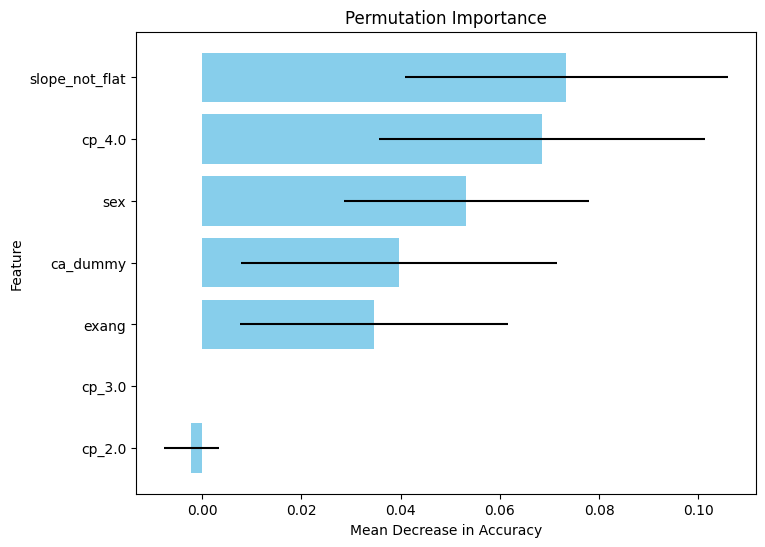

In [707]:
# Permutation importance for the logistic regression model
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
# Define predictors and target for training and test data
predictors = ['sex','exang', 'ca_dummy', 'slope_not_flat', 'cp_2.0', 'cp_3.0', 'cp_4.0']
X_train = train_data[predictors]
y_train = train_data['target']
X_test = test_data[predictors]
y_test = test_data['target']

# Train a logistic regression model using sklearn
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Compute permutation importance on the test data
perm_importance = permutation_importance(log_reg, X_test, y_test, scoring='accuracy', n_repeats=100, random_state=1001)

# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': predictors,
    'Importance': perm_importance.importances_mean,
    'Std Dev': perm_importance.importances_std
}).sort_values(by='Importance', ascending=False)

# Display feature importance
print("\nPermutation Importance:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], xerr=importance_df['Std Dev'], color='skyblue')
plt.xlabel('Mean Decrease in Accuracy')
plt.ylabel('Feature')
plt.title('Permutation Importance')
plt.gca().invert_yaxis()
plt.show()